In [1]:
from pathlib import Path as p
from IPython.display import display
from scipy.stats import gaussian_kde
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit


import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
import joblib


In [2]:
def list_files(dir):
    for item in sorted(dir.iterdir()):
        item_type = 'folder' if item.is_dir() else 'file'
        print(f"- [{item_type}] {item.name}")

curr_dir = p.cwd()

print(f"Current working directory: {curr_dir}")
print("\n Files and Folders found: ")

list_files(curr_dir)

Current working directory: C:\Users\chari\Desktop\airqo_cole_charis_assgnmnt

 Files and Folders found: 
- [folder] .claude
- [folder] .git
- [folder] .idea
- [file] AI Model Deployment and Scalability Assignment 4.pdf
- [file] Assignment 4 - AirQo PM2.5 Prediction.pdf
- [file] best_pm25_model.joblib
- [file] requirements.txt
- [file] Sensor Data Jan - July 2026.csv
- [file] train.ipynb


In [3]:
data_file = p('Sensor Data Jan - July 2026.csv')
data = pd.read_csv(data_file)

In [4]:
print(f"Rows: {data.shape[0]}")
print(f"Columns: {data.shape[1]}")
print(f"Column Names: {data.columns.tolist()}")
print()

Rows: 14600
Columns: 12
Column Names: ['site_name', 'datetime', 'frequency', 'network', 'latitude', 'longitude', 'temperature', 'humidity', 'pm2_5_calibrated_value', 'pm10_calibrated_value', 'site_id', 'device_name']



In [5]:
print("Data Types; ")
print(data.dtypes)

Data Types; 
site_name                  object
datetime                   object
frequency                  object
network                    object
latitude                  float64
longitude                 float64
temperature               float64
humidity                  float64
pm2_5_calibrated_value    float64
pm10_calibrated_value     float64
site_id                    object
device_name                object
dtype: object


In [6]:
measurement_columns = [
    'latitude',
    'longitude',
    'temperature',
    'humidity',
    'pm2_5_calibrated_value',
    'pm10_calibrated_value'
]

In [7]:
missing_values = pd.DataFrame({
    'null_values' : data[measurement_columns].isna().sum(),
    'zero_values' : (data[measurement_columns]==0).sum()
})

missing_values['total_missing'] = (
    missing_values['null_values'] + missing_values['zero_values']
)

print("Missing values; ")
display(missing_values)

Missing values; 


,null_values,zero_values,total_missing
latitude,1,3085,3086
longitude,0,3067,3067
temperature,54,4066,4120
humidity,206,4159,4365
pm2_5_calibrated_value,325,0,325
pm10_calibrated_value,427,3,430


In [8]:
print("First five rows; ")
display(data.head())

First five rows; 


,site_name,datetime,frequency,network,latitude,longitude,temperature,humidity,pm2_5_calibrated_value,pm10_calibrated_value,site_id,device_name
0,Salama Road,2026-01-01 00:00:00Z,hourly,airgradient,0.33354,32.56861,20.535000,88.405000,181.16,197.89,694140834973ef0013d1a9b0,ag_588c81267534
1,Salama Road,2026-01-01 01:00:00Z,hourly,airgradient,0.33354,32.56861,20.640000,89.610000,290.98,318.91,694140834973ef0013d1a9b0,ag_588c81267534
2,Salama Road,2026-01-01 02:00:00Z,hourly,airgradient,0.33354,32.56861,20.821053,89.610526,274.59,301.09,694140834973ef0013d1a9b0,ag_588c81267534
3,Salama Road,2026-01-01 03:00:00Z,hourly,airgradient,0.33354,32.56861,20.605000,90.055000,242.30,264.05,694140834973ef0013d1a9b0,ag_588c81267534
4,Salama Road,2026-01-01 04:00:00Z,hourly,airgradient,0.33354,32.56861,20.675000,88.715000,206.34,225.85,694140834973ef0013d1a9b0,ag_588c81267534


In [9]:
print("Unique values in categorical columns; ")
for column in ['frequency', 'network', 'site_name', 'device_name']:
    print("\n Column: ")
    print(data[column].unique())

Unique values in categorical columns; 

 Column: 
['hourly']

 Column: 
['airgradient' 'airqo']

 Column: 
['Salama Road' 'Mbarara Central' 'Rakai Health Sciences Program Facility'
 'Mbarara University, Mbarara' 'Kawanda 2' 'Gulu Main Market'
 'kawempe moslem p/s' 'Civic Centre, Kampala Central'
 'Nsasa, Kira Municipality' 'Embassy of France, Lumumba avenue'
 'Kisenyi Health Centre 4 (KCCA)' 'Lorry Park, Fort Portal'
 'Kawaala Health Centre' 'Buganda Road P.S' 'Nile avenue, Kampla, Uganda'
 'Kiswa Health Centre' 'Komamboga Health Centre'
 'Agricultural Resource Centre Kyanja' 'Kamwokya Primary School'
 'Kawempe Division' 'Kololo AirStrip'
 'Makerere University Weather Station 94' 'Nakawa Division KCCA'
 'KCCA Hall,Parliamentary Avenue' 'St Paul Demonstration School,Ggaba'
 'Kololo Mabua Stores' 'Kitebi Health Centre 3,Kabusu road'
 'KCCA Division Kisungu' 'KCCA Stadium Lugogo' 'Namungona Primary school'
 'Kira Road Police, Kira road, Kampala Uganda' 'Bakuli, Kampala, Uganda'
 'Ministry

In [10]:
print(f"Datetime samples: {data['datetime'].head(10).tolist()}")

Datetime samples: ['2026-01-01 00:00:00Z', '2026-01-01 01:00:00Z', '2026-01-01 02:00:00Z', '2026-01-01 03:00:00Z', '2026-01-01 04:00:00Z', '2026-01-01 05:00:00Z', '2026-01-01 06:00:00Z', '2026-01-01 07:00:00Z', '2026-01-01 08:00:00Z', '2026-01-01 09:00:00Z']


In [11]:
print("Numeric description; ")
display(data.describe().T)

Numeric description; 


,count,mean,std,min,25%,50%,75%,max
latitude,14599.0,0.265731,0.680336,-1.2726,0.00000,0.313564,0.351635,2.829097
longitude,14600.0,25.272042,13.158312,0.0000,30.25565,32.552280,32.591359,33.235100
temperature,14546.0,17.295417,11.326213,0.0000,0.00000,21.600000,25.508334,44.510000
humidity,14394.0,56.100501,37.608918,0.0000,0.00000,72.720834,86.264464,99.000000
pm2_5_calibrated_value,14275.0,32.706103,30.364417,4.2900,13.25500,20.840000,44.975000,998.400000
pm10_calibrated_value,14173.0,45.079282,45.226573,0.0000,14.56000,33.890000,59.840000,802.100000


In [12]:
print("Duplicate rows; ")
print(data.duplicated().sum())

Duplicate rows; 


0


In [13]:
print("Rows with missing pm2.5 target; ")

pm2_5 = ['pm2_5_calibrated_value']
missing_pm2_5 = pd.DataFrame({
    'null_values' : data[pm2_5].isna().sum(),
    'zero_values' : (data[pm2_5]==0).sum()
})

missing_pm2_5['total_missing'] = (
    missing_pm2_5['null_values'] + missing_pm2_5['zero_values']
)

display(missing_pm2_5)

Rows with missing pm2.5 target; 


,null_values,zero_values,total_missing
pm2_5_calibrated_value,325,0,325


In [14]:
clean_data = data.copy()

In [15]:
clean_data[measurement_columns] = (clean_data[measurement_columns].replace(0, pd.NA))
clean_data['datetime'] = pd.to_datetime(clean_data['datetime'], format='ISO8601', errors='coerce', utc=True)

In [16]:
print(f"Data shape: {clean_data.shape}")

Data shape: (14600, 12)


In [17]:
print("Invalid datetime values: ")
print(clean_data['datetime'].isna().sum())

print("\n Datetime range; ")
print(f"Earliest: {clean_data['datetime'].min()}")
print(f"Latest: {clean_data['datetime'].max()}")

Invalid datetime values: 


0

 Datetime range; 
Earliest: 2026-01-01 00:00:00+00:00
Latest: 2026-06-03 03:00:00+00:00


In [18]:
print("Missing values after cleaning zeros: ")
print(clean_data.isna().sum())

Missing values after cleaning zeros: 


site_name                    0
datetime                     0
frequency                    0
network                      0
latitude                  3086
longitude                 3067
temperature               4120
humidity                  4365
pm2_5_calibrated_value     325
pm10_calibrated_value      430
site_id                   7508
device_name                  0
dtype: int64


## Data Preparation Pipeline

Following the approach report (Section 1):

**Step 1 — Data types and null standardization.** A value of `0` or empty is treated as missing (not a genuine reading) for `temperature`, `humidity`, `pm2_5_calibrated_value`, `pm10_calibrated_value`, `latitude`, and `longitude` — already applied above via `clean_data`. This step formalizes it and enforces consistent dtypes: `datetime` as UTC datetime, measurement fields as `float64`, and identifiers (`site_id`, `site_name`, `device_name`) as pandas `string`.

Note: `site_id` is missing in ~51% of rows, while `device_name` is fully populated and 1:1 with individual sensors (confirmed above — no duplicate sensor-hour combinations). `device_name` is therefore used as the canonical sensor identifier for grouping/resampling; `site_id` is kept as a passthrough categorical field but not relied on for imputation or grouping.</cell_id>

### Sensor Identifiers

- Uniquely identify sensors relative to their locations, to see how many unique sensor each location has

In [19]:
print("Sensor-level coverage using device_name; ")
sensor_coverage = (clean_data.groupby('device_name', dropna=False).agg(first_timestamp=('datetime', 'min'), last_timestamp=('datetime', 'max'), records=('datetime', 'count'), unique_sites=('site_name', 'nunique'), unique_site_ids=('site_id', 'nunique')).sort_values('records'))

display(sensor_coverage.head(10))

Sensor-level coverage using device_name; 


,first_timestamp,last_timestamp,records,unique_sites,unique_site_ids
device_name,,,,,
ag_588c81266dc8,2026-04-01 05:00:00+00:00,2026-06-02 11:00:00+00:00,20,1,0
airqo_g5367,2026-01-01 07:00:00+00:00,2026-01-02 15:00:00+00:00,21,1,1
airqo_g5339,2026-01-01 00:00:00+00:00,2026-06-02 00:00:00+00:00,23,1,1
aq_04,2026-06-01 06:00:00+00:00,2026-06-02 18:00:00+00:00,27,1,1
aq_48,2026-04-01 16:00:00+00:00,2026-04-02 21:00:00+00:00,30,1,0
airqo_g5564,2026-01-01 00:00:00+00:00,2026-06-02 11:00:00+00:00,33,1,0
airqo_g5204,2026-01-01 07:00:00+00:00,2026-06-02 11:00:00+00:00,34,1,1
airqo_g5305,2026-01-01 07:00:00+00:00,2026-01-02 23:00:00+00:00,37,1,1
aq_27,2026-01-01 00:00:00+00:00,2026-01-02 23:00:00+00:00,39,1,0


### Sensor-Hour uniqueness and coverage

- Check if each device has less/more than one record per hour and hence summarize the amount of data available per device

In [20]:
sensor_hour_duplicates = (
    clean_data.groupby(['device_name', 'datetime'], dropna=False).size().reset_index(name='rows_per_sensor_hour')
)

duplicate_sensor_hours = sensor_hour_duplicates[
    sensor_hour_duplicates['rows_per_sensor_hour'] > 1
]

print("Duplicate sensor-hour combinations:")
print(f"Number of duplicated sensor-hour combinations: {len(duplicate_sensor_hours)}")
print(
    f"Extra rows caused by duplicates: "
    f"{duplicate_sensor_hours['rows_per_sensor_hour'].sub(1).sum()}"
)

print("\n Records per device; ")
records_per_device = (
    clean_data.groupby('device_name', dropna=False).size().rename('records')
)

print(records_per_device.describe())

print("\n Devices with the most records: ")
print(records_per_device.sort_values(ascending=False).head(10))

print("\n Devices with the fewest records: ")
print(records_per_device.sort_values().head(10))

print("\n Sites associated with more than one device: ")
devices_per_site = (
    clean_data.groupby('site_name', dropna=False)['device_name'].nunique().sort_values(ascending=False)
)

print(devices_per_site[devices_per_site > 1 ])

Duplicate sensor-hour combinations:
Number of duplicated sensor-hour combinations: 0
Extra rows caused by duplicates: 0

 Records per device; 
count    149.000000
mean      97.986577
std       39.608385
min       20.000000
25%       58.000000
50%      105.000000
75%      137.000000
max      147.000000
Name: records, dtype: float64

 Devices with the most records: 
device_name
airqo-g5184    147
airqo_g5282    147
aq_66          147
aq_g5_37       147
aq_g519        147
airqo_g5247    146
aq_g535        145
aq_58          145
aq_g517        145
aq_47          145
Name: records, dtype: int64

 Devices with the fewest records: 


device_name
ag_588c81266dc8    20
airqo_g5367        21
airqo_g5339        23
aq_04              27
aq_48              30
airqo_g5564        33
airqo_g5204        34
airqo_g5305        37
aq_27              39
airqo_g5566        40
Name: records, dtype: int64

 Sites associated with more than one device: 
site_name
Makerere University Weather Station 94    3
Civic Centre, Kampala Central             2
Nansana east ward, Wakiso                 2
Name: device_name, dtype: int64


- No duplicate sensor-hour combinations, so, device-name and datetime can be used to identify an individual observation
- Sensor coverage is highly uneven, some having up to 147 records and others having only 20 records
- Multiple devices can belong to one site (hence site_name can't be a sensor identifier)

### Time gaps between consecutive observations for each sensor

In [21]:
sorted_data = clean_data.sort_values(
    ['device_name', 'datetime']
).copy()

sorted_data['time_since_previous_reading'] = (
    sorted_data.groupby('device_name')['datetime'].diff()
)

gap_summary = (
    sorted_data.dropna(subset=['time_since_previous_reading'])['time_since_previous_reading'].value_counts().sort_index()
)

print("Most common time gaps between consecutive readings; ")
print(gap_summary.head(20))

print("\n Time-gap description: ")
print(
    sorted_data['time_since_previous_reading'].dropna().describe()
)

print("\n Number of gaps longer than one hour; ")
long_gaps = sorted_data[
    sorted_data['time_since_previous_reading'] > pd.Timedelta(hours=1)
]

print(len(long_gaps))

print("\n Largest observed gaps: ")
display(
    long_gaps[
        ['device_name', 'datetime', 'time_since_previous_reading']
    ].sort_values('time_since_previous_reading', ascending=False).head(20)
)

Most common time gaps between consecutive readings; 
time_since_previous_reading
0 days 01:00:00    13668
0 days 02:00:00      236
0 days 03:00:00      125
0 days 04:00:00       43
0 days 05:00:00       44
0 days 06:00:00       25
0 days 07:00:00       19
0 days 08:00:00       14
0 days 09:00:00        7
0 days 10:00:00        5
0 days 11:00:00        1
0 days 12:00:00        4
0 days 13:00:00        7
0 days 14:00:00        3
0 days 15:00:00        3
0 days 16:00:00        3
0 days 17:00:00        6
0 days 18:00:00        5
0 days 19:00:00        2
0 days 20:00:00        4
Name: count, dtype: int64

 Time-gap description: 
count                        14451
mean     1 days 04:38:53.734689640
std      9 days 08:28:41.013483450
min                0 days 01:00:00
25%                0 days 01:00:00
50%                0 days 01:00:00
75%                0 days 01:00:00
max              150 days 19:00:00
Name: time_since_previous_reading, dtype: object

 Number of gaps longer than one hour; 

,device_name,datetime,time_since_previous_reading
12732,aq_g4_99,2026-06-02 19:00:00+00:00,150 days 19:00:00
5347,airqo-g5186,2026-04-01 05:00:00+00:00,89 days 20:00:00
8140,aq_g513,2026-04-01 00:00:00+00:00,89 days 15:00:00
6004,airqo_g5342,2026-04-01 06:00:00+00:00,89 days 12:00:00
5429,airqo_g5206,2026-04-02 09:00:00+00:00,89 days 09:00:00
9497,aq_g5_86,2026-04-02 06:00:00+00:00,89 days 08:00:00
6370,airqo_g5375,2026-04-01 00:00:00+00:00,88 days 22:00:00
6919,airqo_g5564,2026-04-01 04:00:00+00:00,88 days 18:00:00
5416,airqo_g5204,2026-04-01 06:00:00+00:00,88 days 17:00:00
8416,aq_g522,2026-04-01 15:00:00+00:00,88 days 15:00:00


- This gives us some insight on the gaps for offline time periods
- Helps us decide where to interpolate and where not to
- short gaps: potentially eligible for interpolation
- long gaps: retained as missing to represent sensor downtime

In [22]:
identifier_columns = ['site_id', 'site_name', 'device_name']

# Measurement fields must be numeric floats; identifiers consistent strings.
# Nullable 'Float64' (not numpy 'float64') is required here since the columns
# already contain pd.NA from the zero -> null replacement above.
clean_data[measurement_columns] = clean_data[measurement_columns].astype('Float64')
clean_data[identifier_columns] = clean_data[identifier_columns].astype('string')

print("Dtypes after enforcement; ")
print(clean_data.dtypes)

Dtypes after enforcement; 
site_name                      string[python]
datetime                  datetime64[ns, UTC]
frequency                              object
network                                object
latitude                              Float64
longitude                             Float64
temperature                           Float64
humidity                              Float64
pm2_5_calibrated_value                Float64
pm10_calibrated_value                 Float64
site_id                        string[python]
device_name                    string[python]
dtype: object


In [23]:
print("Validation summary after Step 1 (types + null standardization); ")

validation_summary = pd.DataFrame({
    'dtype': clean_data.dtypes.astype(str),
    'null_count': clean_data.isna().sum(),
    'zero_count': (clean_data[measurement_columns] == 0).reindex(clean_data.columns, axis=1).sum(),
})

display(validation_summary)

print(f"\n Rows: {clean_data.shape[0]}, Columns: {clean_data.shape[1]}")
print(f"Remaining zero values in measurement columns (should be 0): "
      f"{(clean_data[measurement_columns] == 0).sum().sum()}")

Validation summary after Step 1 (types + null standardization); 


,dtype,null_count,zero_count
site_name,string,0,0.0
datetime,"datetime64[ns, UTC]",0,0.0
frequency,object,0,0.0
network,object,0,0.0
latitude,Float64,3086,0.0
longitude,Float64,3067,0.0
temperature,Float64,4120,0.0
humidity,Float64,4365,0.0
pm2_5_calibrated_value,Float64,325,0.0
pm10_calibrated_value,Float64,430,0.0



 Rows: 14600, Columns: 12
Remaining zero values in measurement columns (should be 0): 0


**Step 2 — Latitude/longitude imputation (Section 1.4).** Missing coordinates are filled with the median latitude/longitude of the sensor's own `site_name`, since coordinates are a site-level (not time-varying) property and median is outlier-resistant to the occasional bad GPS fix.

Six sensors (`airqo_g5367`, `aq_43`, `aq_54`, `aq_79`, `aq_g518`, `aq_g5_50`) have **no valid coordinate reading at all** across their entire history, so there is no within-site median to fall back on — the per-site median leaves these six as `NaN`. They are handled separately in **Step 2b** immediately below via KNN imputation, rather than left missing.

In [24]:
coordinate_columns = ['latitude', 'longitude']

site_median_coords = (
    clean_data.groupby('site_name')[coordinate_columns].median()
)

sites_without_any_valid_coords = site_median_coords[
    site_median_coords.isna().any(axis=1)
].index.tolist()

print(f"Sites with no valid coordinate at all (left as NaN): {len(sites_without_any_valid_coords)}")
print(sites_without_any_valid_coords)

for column in coordinate_columns:
    lookup = site_median_coords[column]
    imputed = clean_data['site_name'].map(lookup)
    clean_data[column] = clean_data[column].fillna(imputed)

Sites with no valid coordinate at all (left as NaN): 6


['Bakuli, Kampala, Uganda', 'Kalerwe, Kawempe', 'Kivubuka Budondo, Jinja', 'Makindye, Lukuli Makindye', 'Ntinda, Nakawa', 'Rushoroza Hill, Kabale']


In [25]:
print("Validation summary after Step 2 (lat/lon imputation); ")

coord_validation = pd.DataFrame({
    'null_count': clean_data[coordinate_columns].isna().sum(),
})
display(coord_validation)

print(
    f"\n Sites with remaining coordinate nulls: "
    f"{clean_data.loc[clean_data['latitude'].isna(), 'site_name'].nunique()} "
    f"(expected {len(sites_without_any_valid_coords)})"
)
print("\n Rows still missing coordinates belong only to; ")
print(
    clean_data.loc[clean_data['latitude'].isna(), 'site_name'].unique()
)

Validation summary after Step 2 (lat/lon imputation); 


,null_count
latitude,247
longitude,247



 Sites with remaining coordinate nulls: 6 (expected 6)

 Rows still missing coordinates belong only to; 
<StringArray>
[  'Bakuli, Kampala, Uganda', 'Makindye, Lukuli Makindye',
          'Kalerwe, Kawempe',            'Ntinda, Nakawa',
   'Kivubuka Budondo, Jinja',    'Rushoroza Hill, Kabale']
Length: 6, dtype: string


**Step 2b — KNN imputation for the 6 no-coordinate sites (revised).** The 6 sites left as `NaN` above never recorded a single valid latitude/longitude, so there is no within-site value to fall back on. Rather than leave them missing, `sklearn.impute.KNNImputer` is used to borrow coordinates from the sites with the *most similar pollutant/weather profile* (mean temperature, humidity, PM2.5, PM10) — a similarity-in-measurement-space proxy for "nearby," since true geographic nearest-neighbour is impossible without any coordinate to anchor these 6 sites to in the first place. Features are standardised before imputing (so PM10's ~0-800 range doesn't dominate distance over temperature's ~0-45 range) and inverse-transformed back to real units afterwards.

This is a deliberate accuracy/honesty trade-off worth stating plainly: it is **not** geographic proximity, and should be described as such in the report.

In [26]:
# Do not invent coordinates for sites with no valid geographic observations.
#
# Coordinates are location data, not ordinary sensor measurements.
# Similar temperature or pollution profiles do not prove that two sites
# are geographically close. Therefore, the six sites without valid
# coordinates remain missing.

knn_coords = pd.DataFrame(
    columns=coordinate_columns,
    index=sites_without_any_valid_coords
)

print("Coordinate KNN imputation was intentionally skipped.")
print(
    f"Sites with no valid coordinates retained as missing: "
    f"{len(sites_without_any_valid_coords)}"
)
print(sites_without_any_valid_coords)

Coordinate KNN imputation was intentionally skipped.
Sites with no valid coordinates retained as missing: 6
['Bakuli, Kampala, Uganda', 'Kalerwe, Kawempe', 'Kivubuka Budondo, Jinja', 'Makindye, Lukuli Makindye', 'Ntinda, Nakawa', 'Rushoroza Hill, Kabale']


In [27]:
# Validate the coordinate decision.
# Sites without any valid coordinate history should remain missing.
print("Validation summary after coordinate handling:")

coordinate_validation = pd.DataFrame({
    'missing_count': clean_data[coordinate_columns].isna().sum(),
    'missing_percentage': (
        clean_data[coordinate_columns].isna().mean().mul(100).round(2)
    )
})

display(coordinate_validation)

remaining_coordinate_sites = (
    clean_data.loc[
        clean_data[coordinate_columns].isna().any(axis=1),
        'site_name'
    ]
    .dropna()
    .unique()
)

print(
    "\nSites with remaining coordinate values missing:"
)
print(remaining_coordinate_sites)

print(
    f"\nNumber of sites without valid coordinates: "
    f"{len(remaining_coordinate_sites)}"
)

print(
    "\nDecision: these sites remain missing and will be excluded "
    "from analyses that require geographic coordinates."
)

Validation summary after coordinate handling:


,missing_count,missing_percentage
latitude,247,1.69
longitude,247,1.69



Sites with remaining coordinate values missing:
<StringArray>
[  'Bakuli, Kampala, Uganda', 'Makindye, Lukuli Makindye',
          'Kalerwe, Kawempe',            'Ntinda, Nakawa',
   'Kivubuka Budondo, Jinja',    'Rushoroza Hill, Kabale']
Length: 6, dtype: string

Number of sites without valid coordinates: 6

Decision: these sites remain missing and will be excluded from analyses that require geographic coordinates.


**Step 3 — Hourly resampling (Sections 1.3 / 7.1).** Each sensor (`device_name`) is reindexed onto a complete hourly timestamp grid spanning **2026-01-01 00:00 to 2026-07-31 23:00 UTC**, matching the window both the brief and decision doc state, so hours the device was offline appear as rows with missing measurements rather than being absent from the index entirely.

No device in the supplied CSV has any reading past **2026-06-03 03:00 UTC** (`last_observed_timestamp`, computed dynamically rather than hardcoded) — the file simply doesn't extend into July. That's kept in mind for **Step 4b**: KNN imputation is only applied up to `last_observed_timestamp`, so the July tail — which has zero ground truth anywhere in the dataset to pattern-match against — stays honestly `NaN` rather than being filled with an unfounded seasonal guess.

Static, sensor-level attributes (`site_name`, `site_id`, `network`, `frequency`, and the now-imputed `latitude`/`longitude`) are constant per `device_name` (confirmed — zero devices have more than one distinct value for any of these), so they are carried onto the newly created rows too; only the time-varying measurement fields (`temperature`, `humidity`, `pm2_5_calibrated_value`, `pm10_calibrated_value`) are genuinely missing for those hours.

In [28]:
# Rebuild the hourly grid with PM2.5 explicitly included.
# This fixes the missing target-column error.

static_columns = [
    'site_name',
    'site_id',
    'network',
    'frequency',
    'latitude',
    'longitude'
]

feature_columns = [
    'temperature',
    'humidity',
    'pm10_calibrated_value'
]

target_column = 'pm2_5_calibrated_value'

time_varying_columns = feature_columns + [target_column]

full_hourly_index = pd.date_range(
    start='2026-01-01 00:00',
    end='2026-07-31 23:00',
    freq='h',
    tz='UTC',
    name='datetime'
)

last_observed_timestamp = clean_data['datetime'].max()

device_attributes = (
    clean_data
    .groupby('device_name', as_index=True)[static_columns]
    .first()
)

device_names = device_attributes.index

full_grid = pd.MultiIndex.from_product(
    [device_names, full_hourly_index],
    names=['device_name', 'datetime']
)

resampled_data = (
    clean_data
    .set_index(['device_name', 'datetime'])[time_varying_columns]
    .reindex(full_grid)
    .join(device_attributes, on='device_name')
    .reset_index()
)

resampled_data = resampled_data[
    ['device_name', 'datetime'] + static_columns + time_varying_columns
]

print(f"Resampled shape: {resampled_data.shape}")
print("\nColumns now present:")
print(resampled_data.columns.tolist())

print("\nMissing PM2.5 values:")
print(resampled_data[target_column].isna().sum())


Resampled shape: (758112, 12)

Columns now present:
['device_name', 'datetime', 'site_name', 'site_id', 'network', 'frequency', 'latitude', 'longitude', 'temperature', 'humidity', 'pm10_calibrated_value', 'pm2_5_calibrated_value']

Missing PM2.5 values:
743837


In [29]:
# Validate the complete hourly sensor grid after resampling

print("Validation summary after hourly resampling:")

print(
    f"\nUnique devices: "
    f"{resampled_data['device_name'].nunique()} "
    f"(expected {len(device_names)})"
)

print(
    "Duplicate (device, hour) rows: "
    f"{resampled_data.duplicated(['device_name', 'datetime']).sum()}"
)

print(
    "\nRows before resampling: "
    f"{clean_data.shape[0]}"
)

print(
    "Rows after resampling: "
    f"{resampled_data.shape[0]}"
)

print(
    "Rows added by resampling: "
    f"{resampled_data.shape[0] - clean_data.shape[0]}"
)

print("\nMissing values in static columns:")
display(
    resampled_data[static_columns]
    .isna()
    .sum()
    .rename('missing_count')
    .to_frame()
)

print("\nMissing values in time-varying columns:")
display(
    resampled_data[time_varying_columns]
    .isna()
    .sum()
    .rename('missing_count')
    .to_frame()
)

print("\nTimestamp validation:")
print(f"Earliest timestamp: {resampled_data['datetime'].min()}")
print(f"Latest timestamp:   {resampled_data['datetime'].max()}")
print(
    "Rows outside the original observed period: "
    f"{(resampled_data['datetime'] > last_observed_timestamp).sum()}"
)

Validation summary after hourly resampling:

Unique devices: 149 (expected 149)


Duplicate (device, hour) rows: 0

Rows before resampling: 14600
Rows after resampling: 758112
Rows added by resampling: 743512

Missing values in static columns:


,missing_count
site_name,0
site_id,366336
network,0
frequency,0
latitude,30528
longitude,30528



Missing values in time-varying columns:


,missing_count
temperature,747632
humidity,747877
pm10_calibrated_value,743942
pm2_5_calibrated_value,743837



Timestamp validation:
Earliest timestamp: 2026-01-01 00:00:00+00:00
Latest timestamp:   2026-07-31 23:00:00+00:00
Rows outside the original observed period: 210388


In [30]:
# Mark whether each sensor-hour was present in the original dataset.
#
# True  = no original sensor reading existed for this hour
# False = an original sensor reading existed for this hour

observed_sensor_hours = pd.MultiIndex.from_frame(
    clean_data[
        ['device_name', 'datetime']
    ].drop_duplicates()
)

resampled_sensor_hours = pd.MultiIndex.from_frame(
    resampled_data[
        ['device_name', 'datetime']
    ]
)

resampled_data['is_offline'] = (
    ~resampled_sensor_hours.isin(observed_sensor_hours)
)

print("Offline flag recreated successfully.")
print(
    f"Offline rows: "
    f"{resampled_data['is_offline'].sum()}"
)
print(
    f"Rows with original observations: "
    f"{(~resampled_data['is_offline']).sum()}"
)

Offline flag recreated successfully.
Offline rows: 743512
Rows with original observations: 14600


In [31]:
# Interpolate only short interior gaps in feature measurements.
#
# PM2.5 is the prediction target, so it is deliberately excluded.
# Missing PM2.5 values must remain missing and will not become invented
# training targets.

feature_interpolation_columns = [
    'temperature',
    'humidity',
    'pm10_calibrated_value'
]

target_column = 'pm2_5_calibrated_value'
MAX_INTERPOLATION_GAP_HOURS = 3


def interpolate_short_gaps(
    series,
    max_gap=MAX_INTERPOLATION_GAP_HOURS
):
    """
    Linearly interpolate only interior missing runs whose length is
    at most max_gap hours.

    Longer gaps and leading/trailing missing runs remain missing.
    """
    is_missing = series.isna()

    run_id = (
        is_missing.ne(is_missing.shift())
        .cumsum()
    )

    run_length = (
        is_missing
        .groupby(run_id)
        .transform('size')
    )

    short_interior_gap = (
        is_missing
        & (run_length <= max_gap)
    )

    interpolated = series.interpolate(
        method='linear',
        limit_area='inside'
    )

    result = series.copy()
    result.loc[short_interior_gap] = (
        interpolated.loc[short_interior_gap]
    )

    return result


# Record which values were missing before feature interpolation.
for column in feature_interpolation_columns:
    resampled_data[f'{column}_pre_interpolation_na'] = (
        resampled_data[column].isna()
    )

# Interpolate only the selected feature columns within each sensor.
resampled_data = (
    resampled_data
    .sort_values(['device_name', 'datetime'])
    .reset_index(drop=True)
)

for column in feature_interpolation_columns:
    resampled_data[column] = (
        resampled_data
        .groupby('device_name')[column]
        .transform(interpolate_short_gaps)
    )

# Record whether PM2.5 was observed after resampling/interpolation.
# This should remain false for absent or missing target readings.
resampled_data['pm2_5_observed'] = (
    resampled_data[target_column].notna()
)

print("Interpolation completed for feature columns only:")
print(feature_interpolation_columns)

print("\nPM2.5 interpolation:")
print("Not applied — missing PM2.5 values remain missing.")


Interpolation completed for feature columns only:
['temperature', 'humidity', 'pm10_calibrated_value']

PM2.5 interpolation:
Not applied — missing PM2.5 values remain missing.


In [32]:
# Validate feature interpolation and target preservation

print("Validation after short-gap feature interpolation:")

validation_after_interpolation = pd.DataFrame({
    'missing_count': resampled_data[
        feature_columns + [target_column]
    ].isna().sum(),
    'missing_percentage': (
        resampled_data[
            feature_columns + [target_column]
        ].isna().mean().mul(100).round(2)
    )
})

display(validation_after_interpolation)

print("\nPM2.5 target validation:")
print(
    f"Missing PM2.5 values: "
    f"{resampled_data[target_column].isna().sum()}"
)
print(
    f"Observed PM2.5 values: "
    f"{resampled_data[target_column].notna().sum()}"
)

print("\nOffline-hour validation:")
print(
    f"Offline rows: "
    f"{resampled_data['is_offline'].sum()}"
)
print(
    f"Observed rows: "
    f"{(~resampled_data['is_offline']).sum()}"
)

print("\nRows after the last real observation:")
print(
    f"{(resampled_data['datetime'] > last_observed_timestamp).sum()}"
)

print("\nInterpolation marker columns:")
display(
    resampled_data.filter(
        regex='_pre_interpolation_na$'
    ).sum()
    .rename('values_missing_before_interpolation')
    .to_frame()
)


Validation after short-gap feature interpolation:


,missing_count,missing_percentage
temperature,747056,98.54
humidity,747292,98.57
pm10_calibrated_value,743098,98.02
pm2_5_calibrated_value,743837,98.12



PM2.5 target validation:
Missing PM2.5 values: 743837
Observed PM2.5 values: 14275

Offline-hour validation:
Offline rows: 743512
Observed rows: 14600

Rows after the last real observation:
210388

Interpolation marker columns:


,values_missing_before_interpolation
temperature_pre_interpolation_na,747632
humidity_pre_interpolation_na,747877
pm10_calibrated_value_pre_interpolation_na,743942


In [33]:
# Create the official EDA dataset from genuine observed PM2.5 readings.
# Missing PM2.5 values are excluded from this target-focused analysis.

eda_observed = (
    clean_data[
        clean_data['pm2_5_calibrated_value'].notna()
    ]
    .copy()
    .sort_values(['device_name', 'datetime'])
    .reset_index(drop=True)
)

# Calculate the IQR limits separately for each sensor.
# Sensor-specific limits are preferable because sensors and locations
# may have different typical PM2.5 levels.

pm25_sensor_summary = (
    eda_observed
    .groupby('device_name')['pm2_5_calibrated_value']
    .agg(
        q1=lambda values: values.quantile(0.25),
        median='median',
        q3=lambda values: values.quantile(0.75),
        observations='count'
    )
)

pm25_sensor_summary['iqr'] = (
    pm25_sensor_summary['q3']
    - pm25_sensor_summary['q1']
)

pm25_sensor_summary['lower_limit'] = (
    pm25_sensor_summary['q1']
    - 1.5 * pm25_sensor_summary['iqr']
)

pm25_sensor_summary['upper_limit'] = (
    pm25_sensor_summary['q3']
    + 1.5 * pm25_sensor_summary['iqr']
)

# Attach each sensor's limits to its observations.
eda_observed = eda_observed.join(
    pm25_sensor_summary[
        ['lower_limit', 'upper_limit']
    ],
    on='device_name'
)

# Flag potential IQR outliers without removing them.
eda_observed['pm25_iqr_outlier'] = (
    (eda_observed['pm2_5_calibrated_value'] < eda_observed['lower_limit'])
    | (eda_observed['pm2_5_calibrated_value'] > eda_observed['upper_limit'])
)

print("Observed PM2.5 EDA dataset:")
print(f"Rows: {len(eda_observed)}")
print(f"Sensors: {eda_observed['device_name'].nunique()}")

print("\nPotential PM2.5 outliers:")
print(
    f"{eda_observed['pm25_iqr_outlier'].sum()} "
    f"of {len(eda_observed)} observations "
    f"({eda_observed['pm25_iqr_outlier'].mean() * 100:.2f}%)"
)

print("\nPotential outliers by sensor:")
outlier_summary = (
    eda_observed
    .groupby('device_name')
    .agg(
        observations=('pm2_5_calibrated_value', 'count'),
        potential_outliers=('pm25_iqr_outlier', 'sum'),
        maximum_pm25=('pm2_5_calibrated_value', 'max')
    )
)

outlier_summary['outlier_percentage'] = (
    100
    * outlier_summary['potential_outliers']
    / outlier_summary['observations']
)

print(
    outlier_summary
    .sort_values('potential_outliers', ascending=False)
    .head(15)
)

print("\nLargest observed PM2.5 values:")
print(
    eda_observed[
        [
            'device_name',
            'site_name',
            'datetime',
            'pm2_5_calibrated_value',
            'pm25_iqr_outlier'
        ]
    ]
    .sort_values(
        'pm2_5_calibrated_value',
        ascending=False
    )
    .head(15)
)

Observed PM2.5 EDA dataset:
Rows: 14275
Sensors: 149

Potential PM2.5 outliers:
652 of 14275 observations (4.57%)

Potential outliers by sensor:
             observations  potential_outliers  maximum_pm25  \
device_name                                                   
aq_g5_117             143                  19        158.65   
aq_g5_37              147                  17         188.2   
aq_g5_59              141                  17        107.58   
aq_g5_4               119                  17        182.71   
aq_g503                97                  16          94.9   
aq_g530               143                  15         59.44   
aq_g5_79              126                  15         63.46   
aq_g5_114             141                  15         75.69   
airqo_g5293            94                  14        144.04   
airqo_g5548           120                  14        111.76   
airqo_g5368           127                  13        113.81   
airqo-g5184           144           

In [34]:
# Inspect the context surrounding the most extreme PM2.5 observations.
# This helps distinguish plausible pollution episodes from sensor errors.

context_columns = [
    'device_name',
    'site_name',
    'datetime',
    'temperature',
    'humidity',
    'pm2_5_calibrated_value',
    'pm10_calibrated_value',
    'pm25_iqr_outlier'
]

extreme_pm25_context = (
    eda_observed[
        eda_observed['pm2_5_calibrated_value'] >= 200
    ][context_columns]
    .sort_values(
        'pm2_5_calibrated_value',
        ascending=False
    )
)

print(
    f"Observations with PM2.5 >= 200 µg/m³: "
    f"{len(extreme_pm25_context)}"
)

print(extreme_pm25_context.head(25))

Observations with PM2.5 >= 200 µg/m³: 13
         device_name                  site_name                  datetime  \
249  ag_588c81266dc8  Nansana east ward, Wakiso 2026-06-01 06:00:00+00:00   
242  ag_588c81266dc8  Nansana east ward, Wakiso 2026-04-02 06:00:00+00:00   
251  ag_588c81266dc8  Nansana east ward, Wakiso 2026-06-01 10:00:00+00:00   
248  ag_588c81266dc8  Nansana east ward, Wakiso 2026-06-01 05:00:00+00:00   
257  ag_588c81267534                Salama Road 2026-01-01 01:00:00+00:00   
110  ag_588c8125ef30      Sir Apollo Kagwa Road 2026-04-02 05:00:00+00:00   
258  ag_588c81267534                Salama Road 2026-01-01 02:00:00+00:00   
230  ag_588c81266ad0    Mpelerwe Trading Center 2026-06-02 20:00:00+00:00   
45   ag_588c8125eca4                   Kyebando 2026-06-01 01:00:00+00:00   
259  ag_588c81267534                Salama Road 2026-01-01 03:00:00+00:00   
109  ag_588c8125ef30      Sir Apollo Kagwa Road 2026-04-02 04:00:00+00:00   
260  ag_588c81267534               

In [35]:
# Check whether PM2.5 values are physically consistent with PM10.
# PM2.5 is normally expected to be less than or equal to PM10.

pm_comparison = eda_observed[
    [
        'device_name',
        'site_name',
        'datetime',
        'pm2_5_calibrated_value',
        'pm10_calibrated_value',
        'temperature',
        'humidity'
    ]
].dropna(
    subset=[
        'pm2_5_calibrated_value',
        'pm10_calibrated_value'
    ]
).copy()

pm_comparison['pm25_to_pm10_ratio'] = (
    pm_comparison['pm2_5_calibrated_value']
    / pm_comparison['pm10_calibrated_value']
)

pm_comparison['pm25_exceeds_pm10'] = (
    pm_comparison['pm2_5_calibrated_value']
    > pm_comparison['pm10_calibrated_value']
)

print("PM2.5 versus PM10 consistency:")
print(
    f"Rows with PM2.5 > PM10: "
    f"{pm_comparison['pm25_exceeds_pm10'].sum()}"
)
print(
    f"Percentage of comparable rows: "
    f"{pm_comparison['pm25_exceeds_pm10'].mean() * 100:.2f}%"
)

print("\nLargest PM2.5-to-PM10 ratios:")
print(
    pm_comparison
    .sort_values('pm25_to_pm10_ratio', ascending=False)
    .head(20)
)

PM2.5 versus PM10 consistency:
Rows with PM2.5 > PM10: 3199
Percentage of comparable rows: 22.58%

Largest PM2.5-to-PM10 ratios:
       device_name                            site_name  \
4723   airqo_g5499                            Nyabuhama   
6573         aq_23             Jinja Main Street, Jinja   
5305   airqo_g5548                        Mbuya_Nadiope   
11837    aq_g5_114                          Layibi Gulu   
6267   airqo_g5573                       Buyala 1 Mpigi   
11704    aq_g5_101  Water and Environment House, Luzira   
13013      aq_g5_5                            Pece Gulu   
14039     aq_g5_79               Lapeta Health Centre 3   
11866    aq_g5_114                          Layibi Gulu   
5939   airqo_g5567                    Kamwokya_OldKiira   
1381   airqo_g5279                     Bugolobi, Nakawa   
5202   airqo_g5545             Bishop Stuart University   
4330   airqo_g5463                             Kenkombe   
9101       aq_g503             Nakawa, KCCA H

In [36]:
# Investigate very small positive PM10 measurements.
# We do not remove or modify them yet.

pm10_low_values = (
    eda_observed[
        eda_observed['pm10_calibrated_value'].notna()
        & (eda_observed['pm10_calibrated_value'] < 1)
    ]
    [
        [
            'device_name',
            'site_name',
            'datetime',
            'pm2_5_calibrated_value',
            'pm10_calibrated_value',
            'temperature',
            'humidity'
        ]
    ]
    .sort_values('pm10_calibrated_value')
)

print(
    f"PM10 observations below 1 µg/m³: "
    f"{len(pm10_low_values)}"
)

print(
    f"Percentage of non-missing PM10 observations: "
    f"{len(pm10_low_values) / eda_observed['pm10_calibrated_value'].notna().sum() * 100:.2f}%"
)

print("\nSmallest positive PM10 observations:")
print(pm10_low_values.head(25))

print("\nSmall PM10 observations by sensor:")
print(
    pm10_low_values
    .groupby('device_name')
    .size()
    .rename('count')
    .sort_values(ascending=False)
    .head(20)
)

PM10 observations below 1 µg/m³: 219
Percentage of non-missing PM10 observations: 1.55%

Smallest positive PM10 observations:
       device_name                               site_name  \
6573         aq_23                Jinja Main Street, Jinja   
4723   airqo_g5499                               Nyabuhama   
5305   airqo_g5548                           Mbuya_Nadiope   
6267   airqo_g5573                          Buyala 1 Mpigi   
14039     aq_g5_79                  Lapeta Health Centre 3   
11837    aq_g5_114                             Layibi Gulu   
11704    aq_g5_101     Water and Environment House, Luzira   
5202   airqo_g5545                Bishop Stuart University   
4330   airqo_g5463                                Kenkombe   
13013      aq_g5_5                               Pece Gulu   
11866    aq_g5_114                             Layibi Gulu   
5939   airqo_g5567                       Kamwokya_OldKiira   
1381   airqo_g5279                        Bugolobi, Nakawa   
13238 

In [37]:
# Create quality flags for PM2.5 and PM10 consistency.
# These flags do not modify or delete any observations.

eda_observed['pm10_very_low'] = (
    eda_observed['pm10_calibrated_value'].notna()
    & (eda_observed['pm10_calibrated_value'] < 1)
)

eda_observed['pm25_exceeds_pm10'] = (
    eda_observed['pm2_5_calibrated_value'].notna()
    & eda_observed['pm10_calibrated_value'].notna()
    & (
        eda_observed['pm2_5_calibrated_value']
        > eda_observed['pm10_calibrated_value']
    )
)

eda_observed['pm_measurement_inconsistency'] = (
    eda_observed['pm10_very_low']
    | eda_observed['pm25_exceeds_pm10']
)

quality_summary = pd.DataFrame({
    'condition': [
        'PM10 below 1 µg/m³',
        'PM2.5 greater than PM10',
        'Any PM measurement inconsistency'
    ],
    'count': [
        eda_observed['pm10_very_low'].sum(),
        eda_observed['pm25_exceeds_pm10'].sum(),
        eda_observed['pm_measurement_inconsistency'].sum()
    ]
})

quality_summary['percentage_of_observed_pm25'] = (
    100
    * quality_summary['count']
    / len(eda_observed)
).round(2)

print(quality_summary)

print("\nQuality flags by sensor:")
print(
    eda_observed
    .groupby('device_name')
    .agg(
        observed_pm25=('pm2_5_calibrated_value', 'count'),
        very_low_pm10=('pm10_very_low', 'sum'),
        pm25_greater_than_pm10=('pm25_exceeds_pm10', 'sum'),
        any_inconsistency=('pm_measurement_inconsistency', 'sum')
    )
    .sort_values('any_inconsistency', ascending=False)
    .head(20)
)

                          condition  count  percentage_of_observed_pm25
0                PM10 below 1 µg/m³    219                         1.53
1           PM2.5 greater than PM10   3199                        22.41
2  Any PM measurement inconsistency   3199                        22.41

Quality flags by sensor:
                 observed_pm25  very_low_pm10  pm25_greater_than_pm10  \
device_name                                                             
aq_g5_117                  143             24                      84   
aq_g5_79                   126              6                      82   
aq_g5_114                  141             26                      74   
aq_g519                    141              5                      70   
aq_g5_93                   119              0                      68   
aq_g5_101                  134             14                      64   
aq_g5_5                    141              4                      60   
airqo_g5279                 9

In [38]:
# Select five Kampala-based sensors for the focused EDA.
#
# Kampala membership is determined using the available coordinates.
# Sites with missing coordinates are not classified as Kampala because
# no artificial geographic positions were created.

KAMPALA_LAT_RANGE = (0.10, 0.45)
KAMPALA_LON_RANGE = (32.45, 32.75)

site_locations = (
    resampled_data[
        [
            'site_name',
            'device_name',
            'latitude',
            'longitude'
        ]
    ]
    .drop_duplicates(subset='site_name')
    .set_index('site_name')
)

is_kampala = (
    site_locations['latitude'].between(*KAMPALA_LAT_RANGE)
    & site_locations['longitude'].between(*KAMPALA_LON_RANGE)
)

kampala_sites = site_locations[is_kampala]

print(
    f"Sites within the Kampala metro bounding box: "
    f"{len(kampala_sites)} of {len(site_locations)}"
)

# Select one representative sensor from each official KCCA division.
# These sites were selected from the named neighbourhoods.
division_representatives = {
    'Central': 'Nakasero II, Kampala 66',
    'Kawempe': 'Bukoto I, Kawempe',
    'Rubaga': 'Kabusu, Natete Road, Kampala, Uganda',
    'Nakawa': 'Mbuya_Nadiope',
    'Makindye': 'Ggaba, Makindye'
}

kampala_selection = pd.DataFrame({
    'division': list(division_representatives.keys()),
    'site_name': list(division_representatives.values())
})

kampala_selection['device_name'] = (
    kampala_selection['site_name']
    .map(site_locations['device_name'])
)

kampala_selection['total_rows'] = (
    kampala_selection['site_name']
    .map(resampled_data.groupby('site_name').size())
)

kampala_selection['observed_records'] = (
    kampala_selection['site_name']
    .map(
        resampled_data[
            ~resampled_data['is_offline']
        ]
        .groupby('site_name')
        .size()
    )
)

kampala_selection['latitude'] = (
    kampala_selection['site_name']
    .map(site_locations['latitude'])
)

kampala_selection['longitude'] = (
    kampala_selection['site_name']
    .map(site_locations['longitude'])
)

print("\nSelected Kampala EDA sensors:")
display(kampala_selection)

# Variables used by the later EDA cells.
eda_site_names = kampala_selection['site_name'].tolist()
eda_device_names = kampala_selection['device_name'].tolist()

eda_data = resampled_data[
    resampled_data['site_name'].isin(eda_site_names)
].copy()

print(f"\nEDA data shape: {eda_data.shape}")
print(f"Selected sites: {len(eda_site_names)}")
print(f"Selected devices: {len(eda_device_names)}")

Sites within the Kampala metro bounding box: 89 of 145



Selected Kampala EDA sensors:


,division,site_name,device_name,total_rows,observed_records,latitude,longitude
0,Central,"Nakasero II, Kampala 66",aq_66,5088,147,0.322967,32.580126
1,Kawempe,"Bukoto I, Kawempe",aq_47,5088,145,0.351673,32.591324
2,Rubaga,"Kabusu, Natete Road, Kampala, Uganda",aq_g5_100,5088,137,0.310772,32.502769
3,Nakawa,Mbuya_Nadiope,airqo_g5548,5088,121,0.326922,32.634422
4,Makindye,"Ggaba, Makindye",aq_g5_46,5088,83,0.258005,32.636959



EDA data shape: (25440, 17)
Selected sites: 5
Selected devices: 5


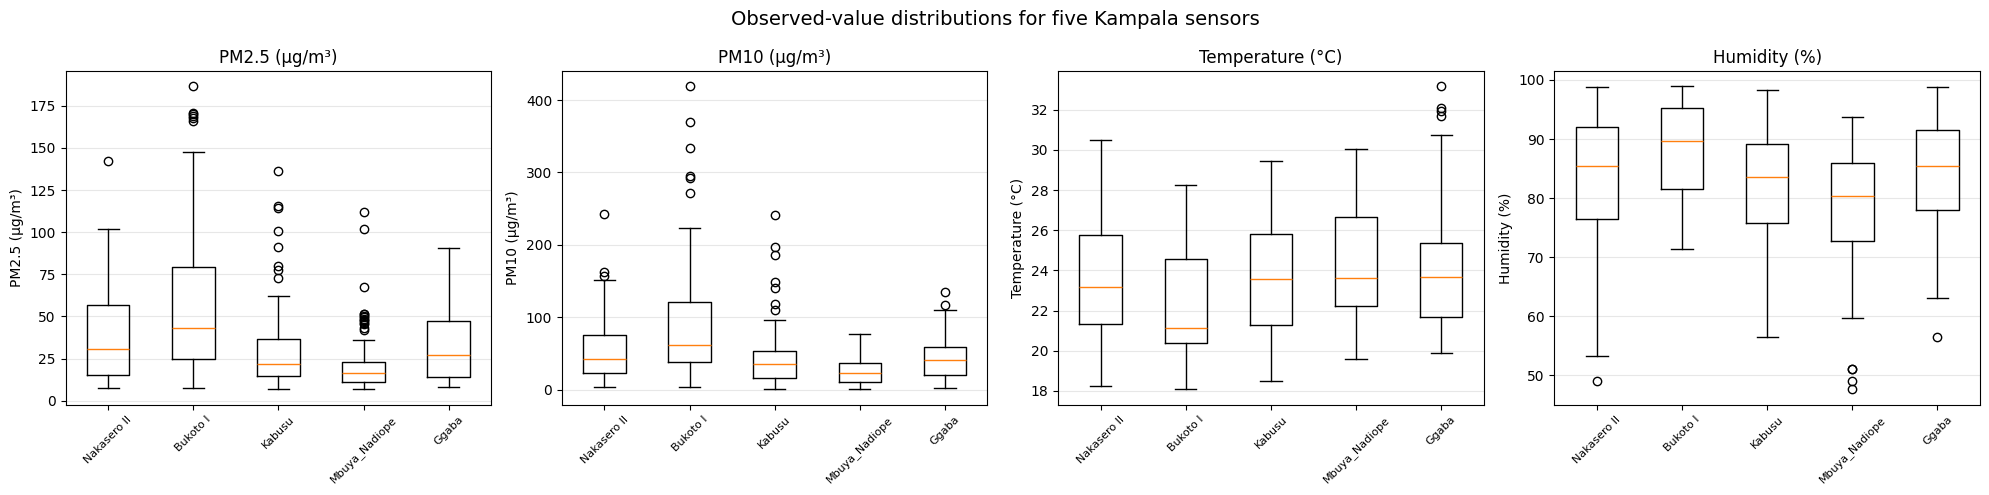

In [39]:
# Box plots for the observed EDA data.
# These plots show the distributions and potential outliers
# for the five selected Kampala sensors.

eda_plot_data = eda_observed[
    eda_observed['site_name'].isin(eda_site_names)
].copy()

plot_columns = [
    'pm2_5_calibrated_value',
    'pm10_calibrated_value',
    'temperature',
    'humidity'
]

plot_labels = {
    'pm2_5_calibrated_value': 'PM2.5 (µg/m³)',
    'pm10_calibrated_value': 'PM10 (µg/m³)',
    'temperature': 'Temperature (°C)',
    'humidity': 'Humidity (%)'
}

fig, axes = plt.subplots(
    1,
    len(plot_columns),
    figsize=(20, 5)
)

for ax, column in zip(axes, plot_columns):
    boxplot_data = [
        eda_plot_data.loc[
            eda_plot_data['site_name'] == site_name,
            column
        ].dropna()
        for site_name in eda_site_names
    ]

    ax.boxplot(
        boxplot_data,
        tick_labels=[
            site_name.split(',')[0][:18]
            for site_name in eda_site_names
        ],
        showfliers=True
    )

    ax.set_title(plot_labels[column])
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_ylabel(plot_labels[column])
    ax.grid(axis='y', alpha=0.3)

fig.suptitle(
    'Observed-value distributions for five Kampala sensors',
    fontsize=14
)

fig.tight_layout()
plt.show()

In [40]:
# Verify the exact box-plot statistics numerically.
# This helps interpret very thin boxes and confirms the number
# of genuine observations contributing to each plot.

boxplot_summary_rows = []

for site_name in eda_site_names:
    site_data = eda_plot_data[
        eda_plot_data['site_name'] == site_name
    ]

    for column in plot_columns:
        values = site_data[column].dropna()

        if len(values) == 0:
            continue

        q1 = values.quantile(0.25)
        median = values.quantile(0.50)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_fence = q1 - 1.5 * iqr
        upper_fence = q3 + 1.5 * iqr

        boxplot_summary_rows.append({
            'site_name': site_name,
            'field': plot_labels[column],
            'observations': len(values),
            'minimum': values.min(),
            'q1': q1,
            'median': median,
            'q3': q3,
            'maximum': values.max(),
            'iqr': iqr,
            'lower_fence': lower_fence,
            'upper_fence': upper_fence,
            'skewness': values.skew()
        })

boxplot_summary = (
    pd.DataFrame(boxplot_summary_rows)
    .sort_values(['field', 'site_name'])
    .round(2)
)

print(boxplot_summary)

                               site_name             field  observations  \
7                      Bukoto I, Kawempe      Humidity (%)            67   
19                       Ggaba, Makindye      Humidity (%)            80   
11  Kabusu, Natete Road, Kampala, Uganda      Humidity (%)           134   
15                         Mbuya_Nadiope      Humidity (%)           120   
3                Nakasero II, Kampala 66      Humidity (%)           147   
5                      Bukoto I, Kawempe      PM10 (µg/m³)           145   
17                       Ggaba, Makindye      PM10 (µg/m³)            83   
9   Kabusu, Natete Road, Kampala, Uganda      PM10 (µg/m³)           134   
13                         Mbuya_Nadiope      PM10 (µg/m³)           117   
1                Nakasero II, Kampala 66      PM10 (µg/m³)           147   
4                      Bukoto I, Kawempe     PM2.5 (µg/m³)           145   
16                       Ggaba, Makindye     PM2.5 (µg/m³)            83   
8   Kabusu, 

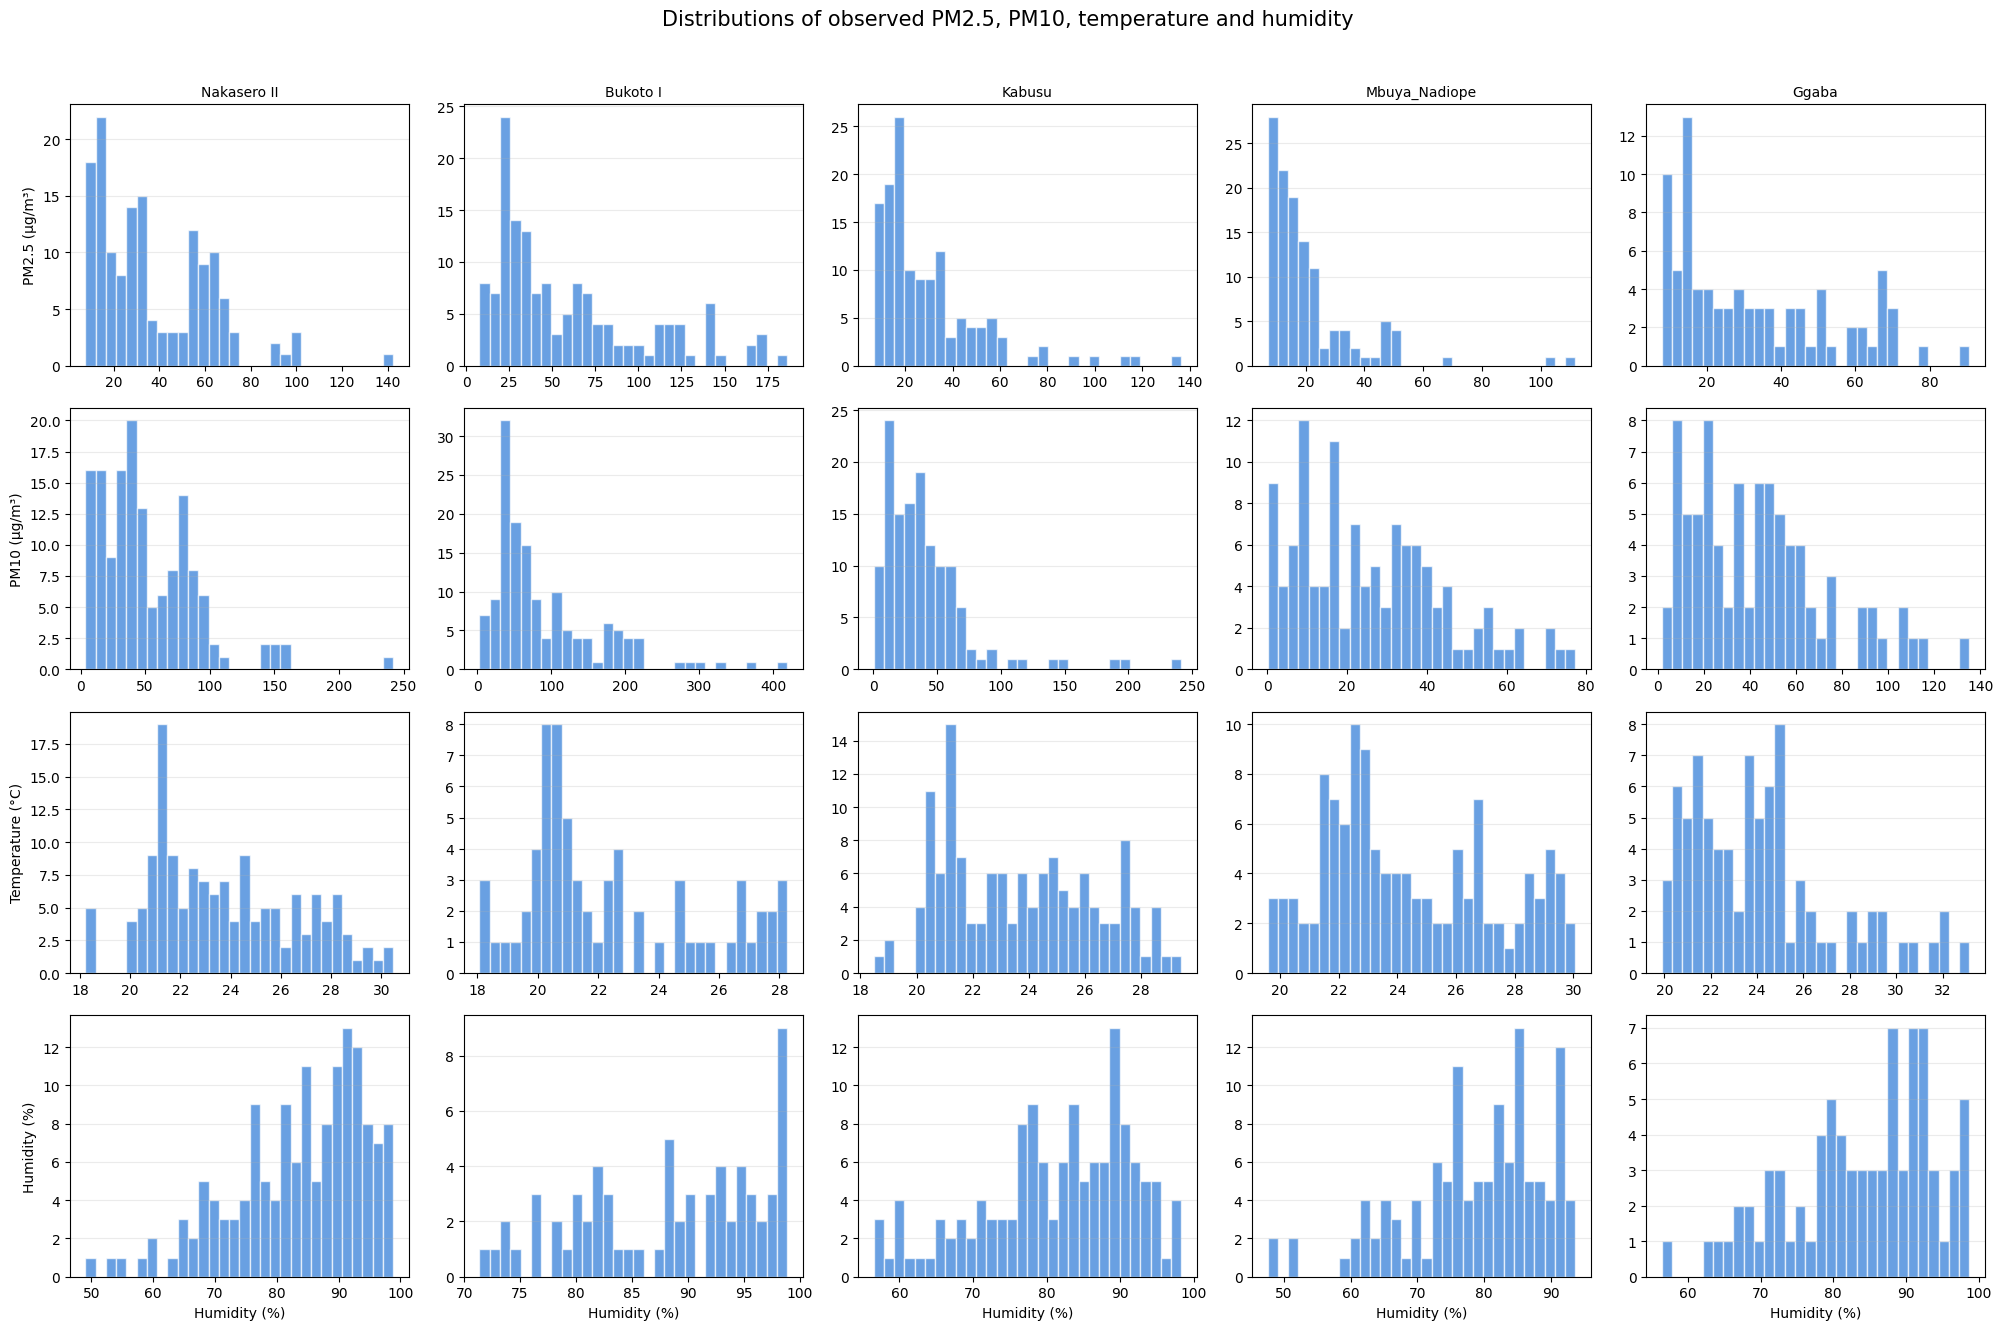

In [41]:
# Distribution plots using genuine observed values only.
# No KNN-imputed or resampled values are used here.

observed_plot_data = eda_observed[
    eda_observed['site_name'].isin(eda_site_names)
].copy()

field_labels = {
    'pm2_5_calibrated_value': 'PM2.5 (µg/m³)',
    'pm10_calibrated_value': 'PM10 (µg/m³)',
    'temperature': 'Temperature (°C)',
    'humidity': 'Humidity (%)'
}

fig, axes = plt.subplots(
    nrows=len(field_labels),
    ncols=len(eda_site_names),
    figsize=(20, 13),
    squeeze=False
)

for row, (field, label) in enumerate(field_labels.items()):
    for col, site_name in enumerate(eda_site_names):
        ax = axes[row, col]

        values = (
            observed_plot_data
            .loc[
                observed_plot_data['site_name'] == site_name,
                field
            ]
            .dropna()
        )

        ax.hist(
            values,
            bins=30,
            color='#2a78d6',
            alpha=0.70,
            edgecolor='white'
        )

        if row == 0:
            ax.set_title(
                site_name.split(',')[0],
                fontsize=10
            )

        if col == 0:
            ax.set_ylabel(label)

        if row == len(field_labels) - 1:
            ax.set_xlabel(label)

        ax.grid(
            axis='y',
            alpha=0.25
        )

fig.suptitle(
    'Distributions of observed PM2.5, PM10, temperature and humidity',
    fontsize=15,
    y=1.02
)

fig.tight_layout()
plt.show()

In [42]:
# Define the PM2.5 AQI categories provided in the assignment.
# The function returns the category for a PM2.5 concentration
# measured in µg/m³.

AQI_CATEGORIES = [
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy',
    'Hazardous'
]

AQI_COLORS = {
    'Good': '#2ca25f',
    'Moderate': '#f1c40f',
    'Unhealthy for Sensitive Groups': '#f39c12',
    'Unhealthy': '#e74c3c',
    'Very Unhealthy': '#8e44ad',
    'Hazardous': '#5b0f14'
}


def pm25_aqi_category(pm25_value):
    """
    Classify a PM2.5 concentration using the assignment's AQI bands.

    Input:
        pm25_value: PM2.5 concentration in µg/m³

    Output:
        AQI category as a string, or <NA> if the input is missing.
    """
    if pd.isna(pm25_value):
        return pd.NA

    if pm25_value < 0:
        return 'Invalid'

    if pm25_value <= 9:
        return 'Good'
    elif pm25_value <= 35.49:
        return 'Moderate'
    elif pm25_value <= 55.49:
        return 'Unhealthy for Sensitive Groups'
    elif pm25_value <= 125.49:
        return 'Unhealthy'
    elif pm25_value <= 225.49:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'


# Apply the category function to the observed PM2.5 data.
eda_observed['pm25_aqi_category'] = (
    eda_observed['pm2_5_calibrated_value']
    .apply(pm25_aqi_category)
)

print("AQI category counts for observed PM2.5:")
print(
    eda_observed['pm25_aqi_category']
    .value_counts()
    .reindex(AQI_CATEGORIES, fill_value=0)
    .rename('observations')
    .to_frame()
)

print("\nExample category assignments:")
print(
    pd.DataFrame({
        'pm25_value': [
            5,
            9,
            20,
            35.49,
            50,
            55.49,
            100,
            125.49,
            200,
            225.49,
            300
        ]
    }).assign(
        category=lambda frame: frame['pm25_value'].apply(
            pm25_aqi_category
        )
    )
)

AQI category counts for observed PM2.5:
                                observations
pm25_aqi_category                           
Good                                    1249
Moderate                                8494
Unhealthy for Sensitive Groups          1820
Unhealthy                               2565
Very Unhealthy                           137
Hazardous                                 10

Example category assignments:
    pm25_value                        category
0         5.00                            Good
1         9.00                            Good
2        20.00                        Moderate
3        35.49                        Moderate
4        50.00  Unhealthy for Sensitive Groups
5        55.49  Unhealthy for Sensitive Groups
6       100.00                       Unhealthy
7       125.49                       Unhealthy
8       200.00                  Very Unhealthy
9       225.49                  Very Unhealthy
10      300.00                       Hazardous


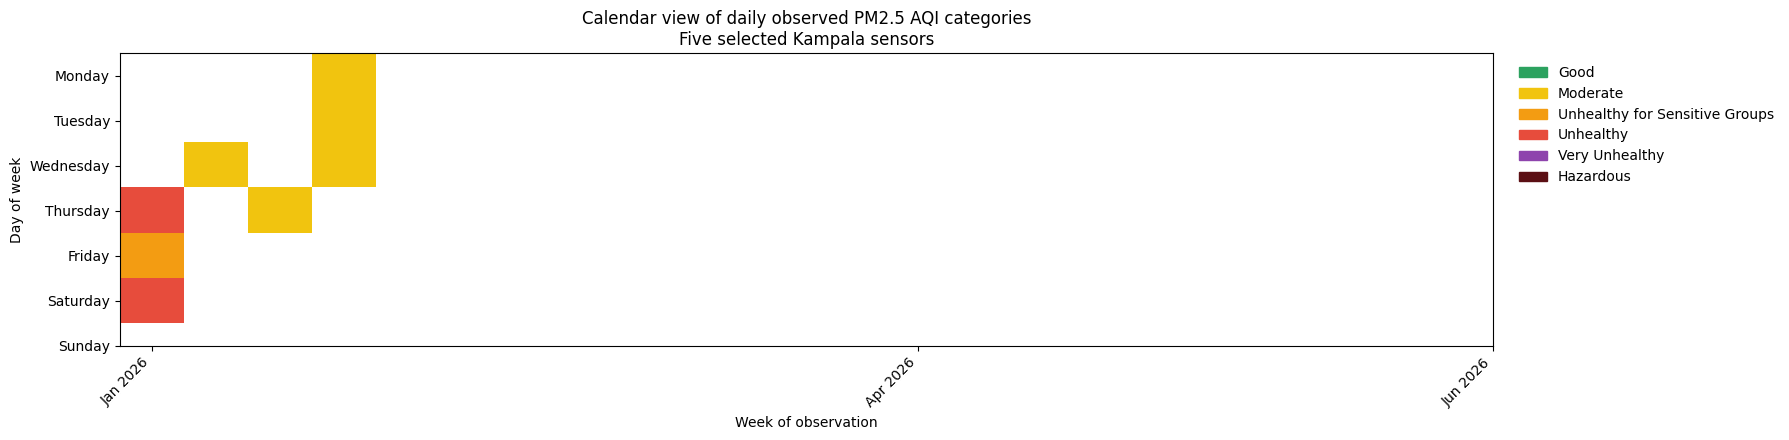

Calendar data summary:
                       date  daily_pm25  contributing_observations  \
0 2026-01-01 00:00:00+00:00   60.981553                        103   
1 2026-01-02 00:00:00+00:00   48.388468                        111   
2 2026-01-03 00:00:00+00:00      78.845                          2   
3 2026-04-01 00:00:00+00:00   27.655161                         93   
4 2026-04-02 00:00:00+00:00   33.455476                         84   

                     aqi_category  week  weekday  week_index  category_number  
0                       Unhealthy     1        3           0                3  
1  Unhealthy for Sensitive Groups     1        4           0                2  
2                       Unhealthy     1        5           0                3  
3                        Moderate    14        2          12                1  
4                        Moderate    14        3          13                1  


In [43]:
# Create a calendar-style plot of daily observed PM2.5.
#
# The daily value is the mean PM2.5 across the five selected Kampala
# sensors for each date. Only genuine observations are used.

calendar_data = (
    eda_observed[
        eda_observed['site_name'].isin(eda_site_names)
    ]
    .assign(
        date=lambda frame: frame['datetime'].dt.floor('D')
    )
    .groupby('date', as_index=False)
    .agg(
        daily_pm25=(
            'pm2_5_calibrated_value',
            'mean'
        ),
        contributing_observations=(
            'pm2_5_calibrated_value',
            'count'
        )
    )
)

calendar_data['aqi_category'] = (
    calendar_data['daily_pm25']
    .apply(pm25_aqi_category)
)

# Create calendar coordinates.
calendar_data['week'] = (
    calendar_data['date']
    .dt.isocalendar()
    .week
    .astype(int)
)

calendar_data['weekday'] = (
    calendar_data['date']
    .dt.weekday
)

# Use a continuous week index so the January-to-June sequence
# appears in chronological order even across ISO-year boundaries.
calendar_data['week_index'] = (
    calendar_data['date']
    .sub(calendar_data['date'].min())
    .dt.days
    .floordiv(7)
)

category_to_number = {
    category: number
    for number, category in enumerate(AQI_CATEGORIES)
}

calendar_data['category_number'] = (
    calendar_data['aqi_category']
    .map(category_to_number)
)

calendar_grid = calendar_data.pivot(
    index='weekday',
    columns='week_index',
    values='category_number'
)

fig, ax = plt.subplots(
    figsize=(18, 4.5)
)

cmap = mpl.colors.ListedColormap(
    [AQI_COLORS[category] for category in AQI_CATEGORIES]
)

norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(
        -0.5,
        len(AQI_CATEGORIES) + 0.5,
        1
    ),
    ncolors=len(AQI_CATEGORIES)
)

ax.imshow(
    calendar_grid,
    aspect='auto',
    cmap=cmap,
    norm=norm,
    interpolation='none'
)

ax.set_yticks(range(7))
ax.set_yticklabels([
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
])

# Identify the first calendar entry for each month
# without converting timezone-aware timestamps to Period values.
month_starts = (
    calendar_data
    .assign(
        month=calendar_data['date'].dt.strftime('%Y-%m')
    )
    .groupby('month', as_index=False)
    .first()
)


ax.set_xticks(month_starts['week_index'])
ax.set_xticklabels(
    month_starts['date'].dt.strftime('%b %Y'),
    rotation=45,
    ha='right'
)

legend_handles = [
    mpl.patches.Patch(
        color=AQI_COLORS[category],
        label=category
    )
    for category in AQI_CATEGORIES
]

ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    frameon=False
)

ax.set_title(
    'Calendar view of daily observed PM2.5 AQI categories\n'
    'Five selected Kampala sensors'
)

ax.set_xlabel('Week of observation')
ax.set_ylabel('Day of week')

plt.tight_layout()
plt.show()

print("Calendar data summary:")
print(calendar_data.head())

In [44]:
# Check which dates have genuine PM2.5 observations
# for the selected Kampala sensors.

daily_coverage = (
    eda_observed[
        eda_observed['site_name'].isin(eda_site_names)
    ]
    .assign(date=lambda frame: frame['datetime'].dt.floor('D'))
    .groupby('date')
    .agg(
        observations=('pm2_5_calibrated_value', 'count'),
        sensors=('device_name', 'nunique')
    )
)

expected_dates = pd.date_range(
    start=eda_observed['datetime'].min().floor('D'),
    end=last_observed_timestamp.floor('D'),
    freq='D',
    tz='UTC'
)

daily_coverage = daily_coverage.reindex(expected_dates)
daily_coverage.index.name = 'date'

print("Daily coverage for selected Kampala sensors:")
print(f"Expected calendar days: {len(expected_dates)}")
print(f"Days with at least one observation: {daily_coverage['observations'].notna().sum()}")
print(f"Days with no observations: {daily_coverage['observations'].isna().sum()}")

print("\nDays with fewer than five observations:")
print(
    daily_coverage[
        daily_coverage['observations'].notna()
        & (daily_coverage['observations'] < 5)
    ]
)

print("\nFirst observed days:")
print(daily_coverage.dropna().head())

print("\nLast observed days:")
print(daily_coverage.dropna().tail())

Daily coverage for selected Kampala sensors:
Expected calendar days: 154
Days with at least one observation: 8
Days with no observations: 146

Days with fewer than five observations:
                           observations  sensors
date                                            
2026-01-03 00:00:00+00:00             2      2.0

First observed days:
                           observations  sensors
date                                            
2026-01-01 00:00:00+00:00           103      5.0
2026-01-02 00:00:00+00:00           111      5.0
2026-01-03 00:00:00+00:00             2      2.0
2026-04-01 00:00:00+00:00            93      5.0
2026-04-02 00:00:00+00:00            84      5.0

Last observed days:
                           observations  sensors
date                                            
2026-04-01 00:00:00+00:00            93      5.0
2026-04-02 00:00:00+00:00            84      5.0
2026-06-01 00:00:00+00:00           110      5.0
2026-06-02 00:00:00+00:00           110

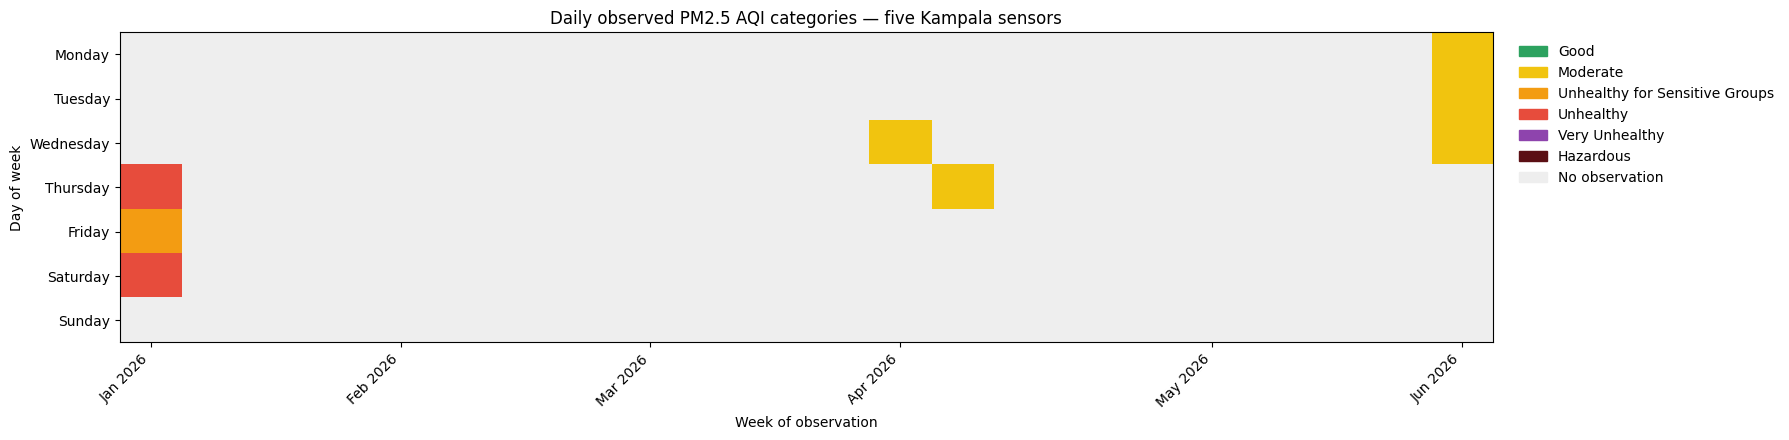

Calendar coverage:
Days with observations: 8
Days without observations: 146


In [45]:
# Build a complete daily calendar for the observed data period.
# Days with no genuine PM2.5 observations remain blank.

calendar_start = eda_observed['datetime'].min().floor('D')
calendar_end = last_observed_timestamp.floor('D')

all_calendar_dates = pd.date_range(
    start=calendar_start,
    end=calendar_end,
    freq='D',
    tz='UTC'
)

daily_pm25 = (
    eda_observed[
        eda_observed['site_name'].isin(eda_site_names)
    ]
    .assign(
        date=lambda frame: frame['datetime'].dt.floor('D')
    )
    .groupby('date')
    .agg(
        daily_pm25=(
            'pm2_5_calibrated_value',
            'mean'
        ),
        contributing_observations=(
            'pm2_5_calibrated_value',
            'count'
        )
    )
    .reindex(all_calendar_dates)
)

daily_pm25.index.name = 'date'
daily_pm25 = daily_pm25.reset_index()

daily_pm25['aqi_category'] = (
    daily_pm25['daily_pm25']
    .apply(pm25_aqi_category)
)

category_to_number = {
    category: number
    for number, category in enumerate(AQI_CATEGORIES)
}

daily_pm25['category_number'] = (
    daily_pm25['aqi_category']
    .map(category_to_number)
)

daily_pm25['weekday'] = (
    daily_pm25['date'].dt.weekday
)

daily_pm25['week_index'] = (
    daily_pm25['date']
    .sub(calendar_start)
    .dt.days
    .floordiv(7)
)

calendar_grid = daily_pm25.pivot(
    index='weekday',
    columns='week_index',
    values='category_number'
)

# Make sure all weekday rows and all week columns exist.
calendar_grid = calendar_grid.reindex(
    index=range(7),
    columns=range(daily_pm25['week_index'].max() + 1)
)

fig, ax = plt.subplots(
    figsize=(18, 4.5)
)

cmap = mpl.colors.ListedColormap(
    [AQI_COLORS[category] for category in AQI_CATEGORIES]
)
cmap.set_bad('#eeeeee')

norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(
        -0.5,
        len(AQI_CATEGORIES) + 0.5,
        1
    ),
    ncolors=len(AQI_CATEGORIES)
)

masked_grid = np.ma.masked_invalid(
    calendar_grid.to_numpy(dtype=float)
)

ax.imshow(
    masked_grid,
    aspect='auto',
    cmap=cmap,
    norm=norm,
    interpolation='none'
)

ax.set_yticks(range(7))
ax.set_yticklabels([
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
])

month_starts = (
    daily_pm25[
        daily_pm25['date'].dt.day == 1
    ]
    .drop_duplicates('week_index')
)

ax.set_xticks(month_starts['week_index'])
ax.set_xticklabels(
    month_starts['date'].dt.strftime('%b %Y'),
    rotation=45,
    ha='right'
)

legend_handles = [
    mpl.patches.Patch(
        color=AQI_COLORS[category],
        label=category
    )
    for category in AQI_CATEGORIES
]

legend_handles.append(
    mpl.patches.Patch(
        color='#eeeeee',
        label='No observation'
    )
)

ax.legend(
    handles=legend_handles,
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    frameon=False
)

ax.set_title(
    'Daily observed PM2.5 AQI categories — five Kampala sensors'
)

ax.set_xlabel('Week of observation')
ax.set_ylabel('Day of week')

plt.tight_layout()
plt.show()

print("Calendar coverage:")
print(
    f"Days with observations: "
    f"{daily_pm25['daily_pm25'].notna().sum()}"
)
print(
    f"Days without observations: "
    f"{daily_pm25['daily_pm25'].isna().sum()}"
)


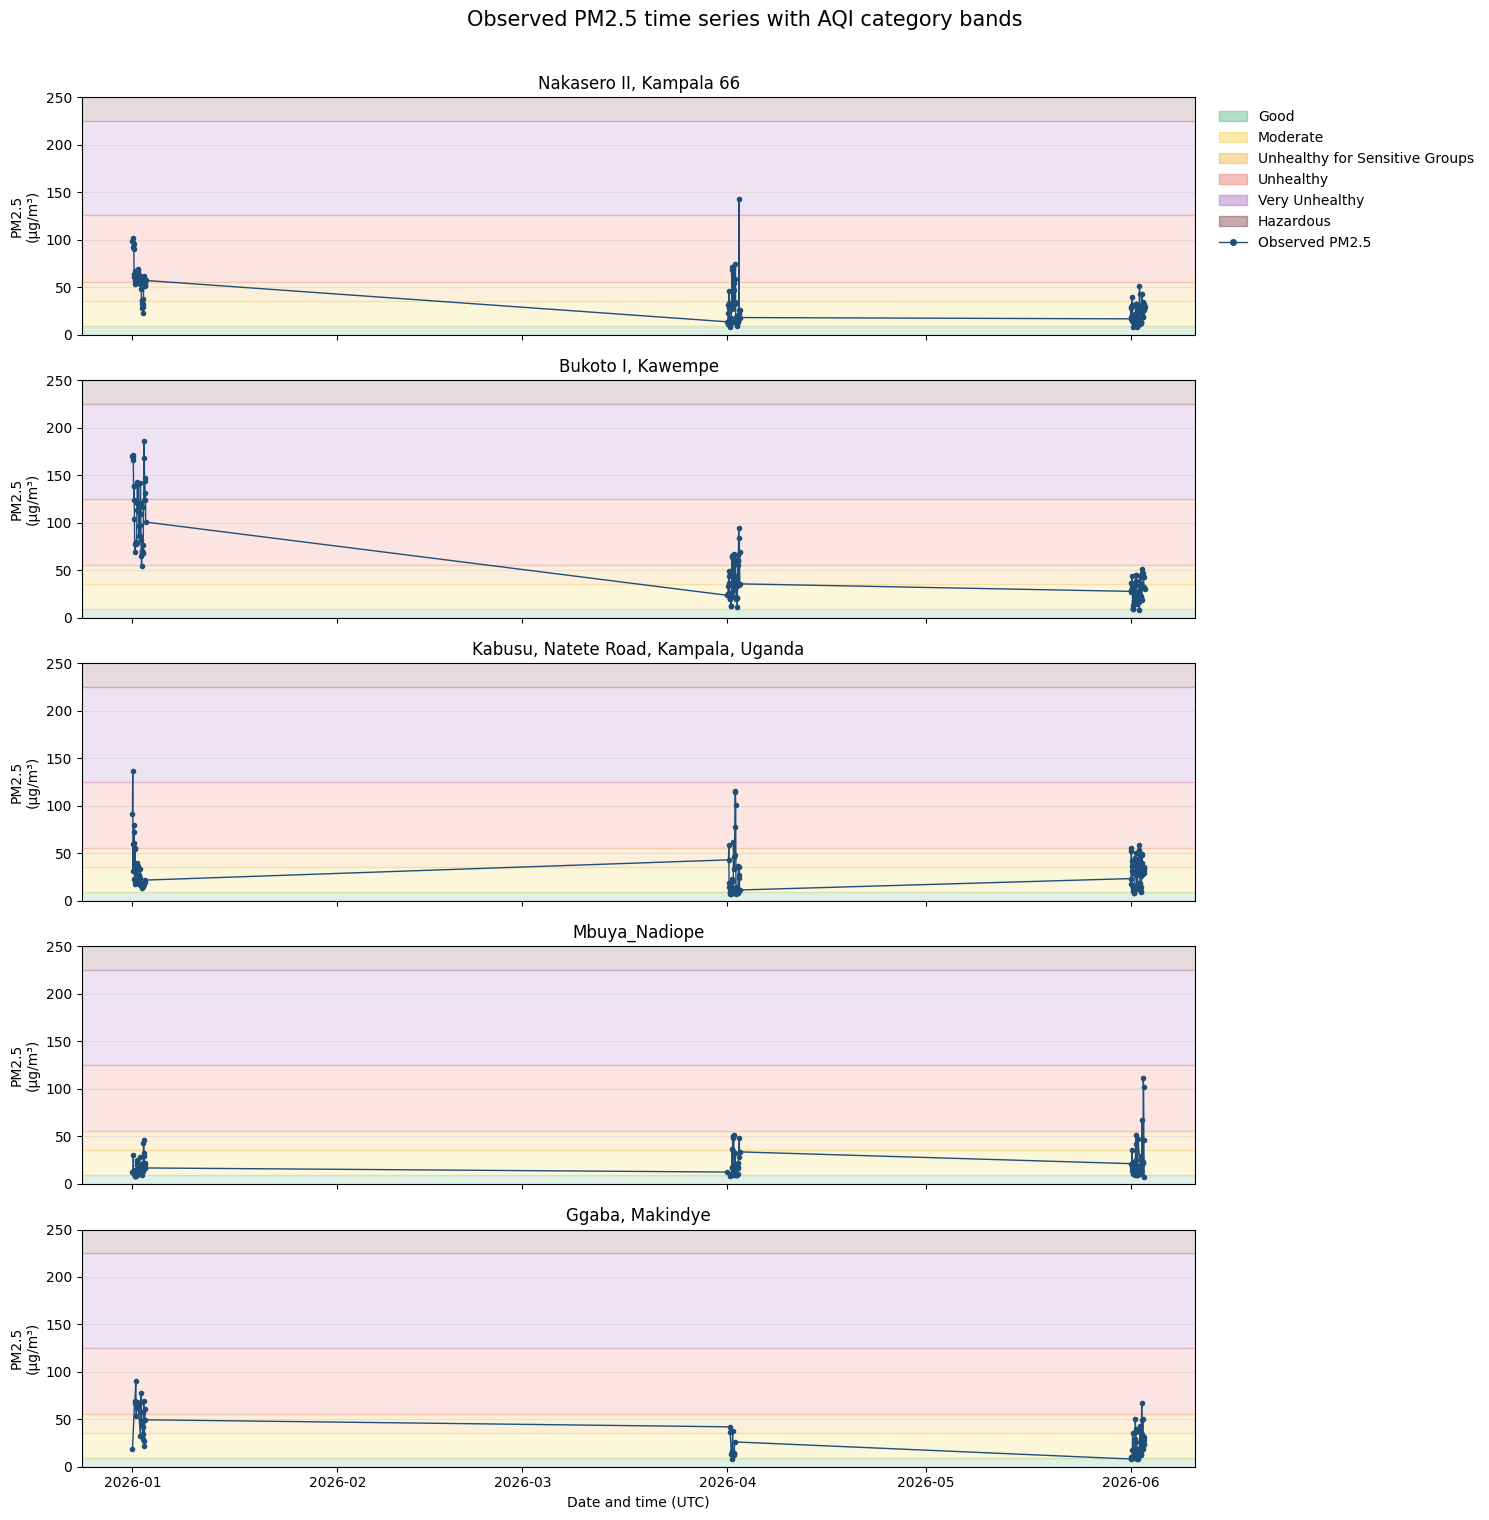

In [46]:
# Plot observed PM2.5 time series for the five selected Kampala sensors.
# Horizontal shaded bands show the AQI categories from the assignment.
# Missing periods remain absent from the lines.

aqi_band_limits = [
    (0, 9, 'Good'),
    (9, 35.49, 'Moderate'),
    (35.49, 55.49, 'Unhealthy for Sensitive Groups'),
    (55.49, 125.49, 'Unhealthy'),
    (125.49, 225.49, 'Very Unhealthy'),
    (225.49, 300, 'Hazardous')
]

fig, axes = plt.subplots(
    nrows=len(eda_site_names),
    ncols=1,
    figsize=(15, 3 * len(eda_site_names)),
    sharex=True
)

# Ensure axes is always iterable
if len(eda_site_names) == 1:
    axes = [axes]

for ax, site_name in zip(axes, eda_site_names):
    sensor_data = (
        eda_observed[
            eda_observed['site_name'] == site_name
        ]
        .sort_values('datetime')
    )

    # Draw AQI background bands.
    for lower, upper, category in aqi_band_limits:
        ax.axhspan(
            lower,
            upper,
            color=AQI_COLORS[category],
            alpha=0.15,
            label=category
        )

    # Plot genuine observed PM2.5 readings only.
    ax.plot(
        sensor_data['datetime'],
        sensor_data['pm2_5_calibrated_value'],
        color='#1f4e79',
        marker='o',
        markersize=3,
        linewidth=1,
        label='Observed PM2.5'
    )

    ax.set_ylabel('PM2.5\n(µg/m³)')
    ax.set_title(site_name)
    ax.grid(axis='y', alpha=0.25)

    # Keep the plot readable while still showing extreme values.
    ax.set_ylim(0, max(
        250,
        sensor_data['pm2_5_calibrated_value'].max() * 1.05
    ))

# Only show one legend for the entire figure.
handles = [
    mpl.patches.Patch(
        color=AQI_COLORS[category],
        alpha=0.35,
        label=category
    )
    for category in AQI_CATEGORIES
]

handles.append(
    plt.Line2D(
        [0],
        [0],
        color='#1f4e79',
        marker='o',
        linewidth=1,
        markersize=4,
        label='Observed PM2.5'
    )
)

axes[0].legend(
    handles=handles,
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    frameon=False
)

axes[-1].set_xlabel('Date and time (UTC)')

fig.suptitle(
    'Observed PM2.5 time series with AQI category bands',
    fontsize=15,
    y=1.01
)

fig.tight_layout()
plt.show()

In [47]:
# Examine the relationship between PM2.5, temperature and humidity
# for the five selected Kampala sensors.
#
# Only genuine observed PM2.5 readings are used.
# Missing values are excluded pairwise for each correlation.

correlation_columns = [
    'pm2_5_calibrated_value',
    'temperature',
    'humidity'
]

correlation_labels = {
    'pm2_5_calibrated_value': 'PM2.5',
    'temperature': 'Temperature',
    'humidity': 'Humidity'
}

kampala_observed = eda_observed[
    eda_observed['site_name'].isin(eda_site_names)
].copy()

correlation_rows = []

for site_name in eda_site_names:
    site_data = kampala_observed[
        kampala_observed['site_name'] == site_name
    ]

    pm25_temperature = site_data[
        ['pm2_5_calibrated_value', 'temperature']
    ].dropna()

    pm25_humidity = site_data[
        ['pm2_5_calibrated_value', 'humidity']
    ].dropna()

    correlation_rows.append({
        'site_name': site_name,
        'pm25_temperature_correlation': (
            pm25_temperature['pm2_5_calibrated_value']
            .corr(pm25_temperature['temperature'])
        ),
        'pm25_temperature_pairs': len(pm25_temperature),
        'pm25_humidity_correlation': (
            pm25_humidity['pm2_5_calibrated_value']
            .corr(pm25_humidity['humidity'])
        ),
        'pm25_humidity_pairs': len(pm25_humidity)
    })

correlation_summary = (
    pd.DataFrame(correlation_rows)
    .set_index('site_name')
    .round(3)
)

print("Pearson correlations for the five selected Kampala sensors:")
print(correlation_summary)

print(
    "\nInterpretation reminder:"
    "\n- A value near +1 indicates a strong positive linear relationship."
    "\n- A value near -1 indicates a strong negative linear relationship."
    "\n- A value near 0 indicates little linear relationship."
    "\n- Correlation does not establish causation."
)

Pearson correlations for the five selected Kampala sensors:
                                      pm25_temperature_correlation  \
site_name                                                            
Nakasero II, Kampala 66                                     -0.133   
Bukoto I, Kawempe                                           -0.247   
Kabusu, Natete Road, Kampala, Uganda                        -0.469   
Mbuya_Nadiope                                               -0.306   
Ggaba, Makindye                                              0.328   

                                      pm25_temperature_pairs  \
site_name                                                      
Nakasero II, Kampala 66                                  147   
Bukoto I, Kawempe                                         67   
Kabusu, Natete Road, Kampala, Uganda                     134   
Mbuya_Nadiope                                            120   
Ggaba, Makindye                                           83   



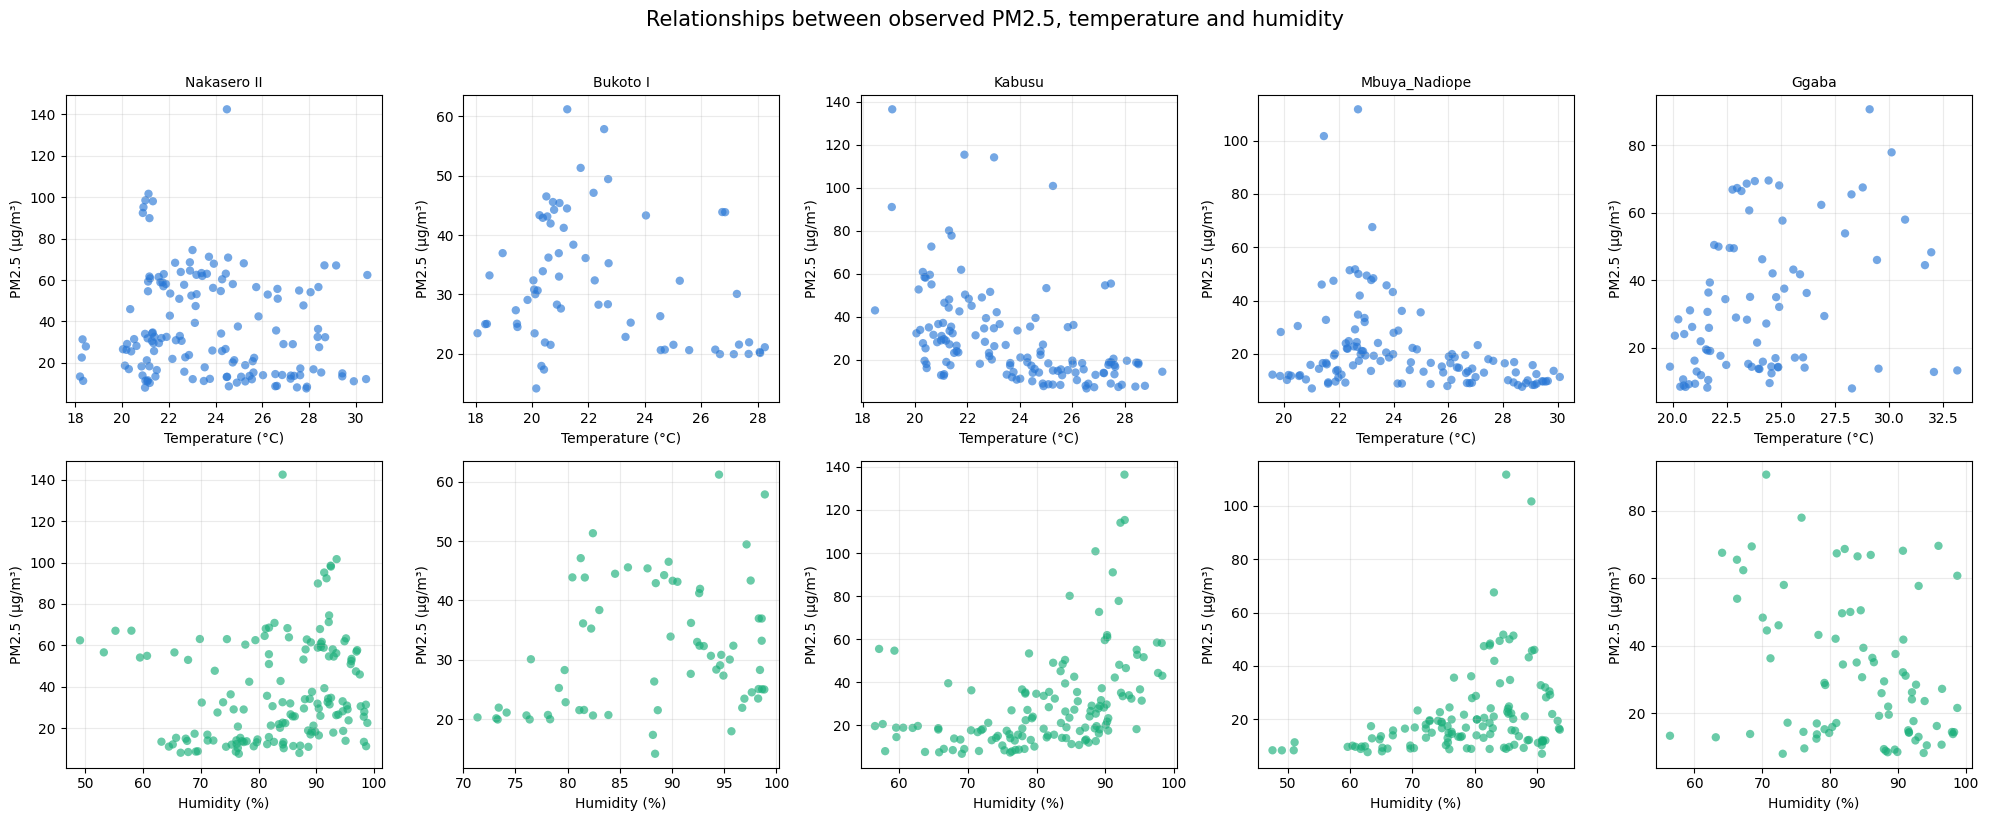

In [48]:
# Scatter plots showing the relationship between PM2.5 and:
# 1. temperature
# 2. humidity
#
# Only paired genuine observations are plotted.

fig, axes = plt.subplots(
    nrows=2,
    ncols=len(eda_site_names),
    figsize=(20, 8),
    squeeze=False
)

for col, site_name in enumerate(eda_site_names):
    site_data = kampala_observed[
        kampala_observed['site_name'] == site_name
    ]

    # PM2.5 versus temperature
    temperature_data = site_data[
        [
            'pm2_5_calibrated_value',
            'temperature'
        ]
    ].dropna()

    axes[0, col].scatter(
        temperature_data['temperature'],
        temperature_data['pm2_5_calibrated_value'],
        color='#2a78d6',
        alpha=0.65,
        edgecolor='none'
    )

    axes[0, col].set_title(
        site_name.split(',')[0],
        fontsize=10
    )

    axes[0, col].set_xlabel('Temperature (°C)')
    axes[0, col].set_ylabel('PM2.5 (µg/m³)')
    axes[0, col].grid(alpha=0.25)

    # PM2.5 versus humidity
    humidity_data = site_data[
        [
            'pm2_5_calibrated_value',
            'humidity'
        ]
    ].dropna()

    axes[1, col].scatter(
        humidity_data['humidity'],
        humidity_data['pm2_5_calibrated_value'],
        color='#1baf7a',
        alpha=0.65,
        edgecolor='none'
    )

    axes[1, col].set_xlabel('Humidity (%)')
    axes[1, col].set_ylabel('PM2.5 (µg/m³)')
    axes[1, col].grid(alpha=0.25)

fig.suptitle(
    'Relationships between observed PM2.5, temperature and humidity',
    fontsize=15,
    y=1.02
)

fig.tight_layout()
plt.show()

In [49]:
# Apply a global Z-score transformation to observed PM2.5.
#
# The transformation is:
#     z = (x - mean) / standard_deviation
#
# This EDA transformation uses observed PM2.5 values only.
# The final model-training scaler must later be fitted on training data only.

pm25_mean_eda = (
    eda_observed['pm2_5_calibrated_value']
    .mean()
)

pm25_std_eda = (
    eda_observed['pm2_5_calibrated_value']
    .std()
)

eda_observed['pm25_zscore'] = (
    eda_observed['pm2_5_calibrated_value']
    - pm25_mean_eda
) / pm25_std_eda

print("PM2.5 statistics used for the EDA Z-score transformation:")
print(f"Mean: {pm25_mean_eda:.3f} µg/m³")
print(f"Standard deviation: {pm25_std_eda:.3f} µg/m³")

print("\nZ-score summary:")
print(
    eda_observed['pm25_zscore']
    .describe()
    .to_frame('pm25_zscore')
    .round(3)
)

print("\nExample transformed values:")
print(
    eda_observed[
        [
            'pm2_5_calibrated_value',
            'pm25_zscore'
        ]
    ]
    .head(10)
    .round(3)
)

PM2.5 statistics used for the EDA Z-score transformation:
Mean: 32.706 µg/m³
Standard deviation: 30.364 µg/m³

Z-score summary:
       pm25_zscore
count      14275.0
mean           0.0
std            1.0
min         -0.936
25%         -0.641
50%         -0.391
75%          0.404
max         31.803

Example transformed values:
   pm2_5_calibrated_value  pm25_zscore
0                    36.9        0.138
1                    80.7        1.581
2                   56.25        0.775
3                   67.15        1.134
4                   97.95        2.149
5                   44.36        0.384
6                   31.09       -0.053
7                   23.59         -0.3
8                   22.48       -0.337
9                   18.62       -0.464


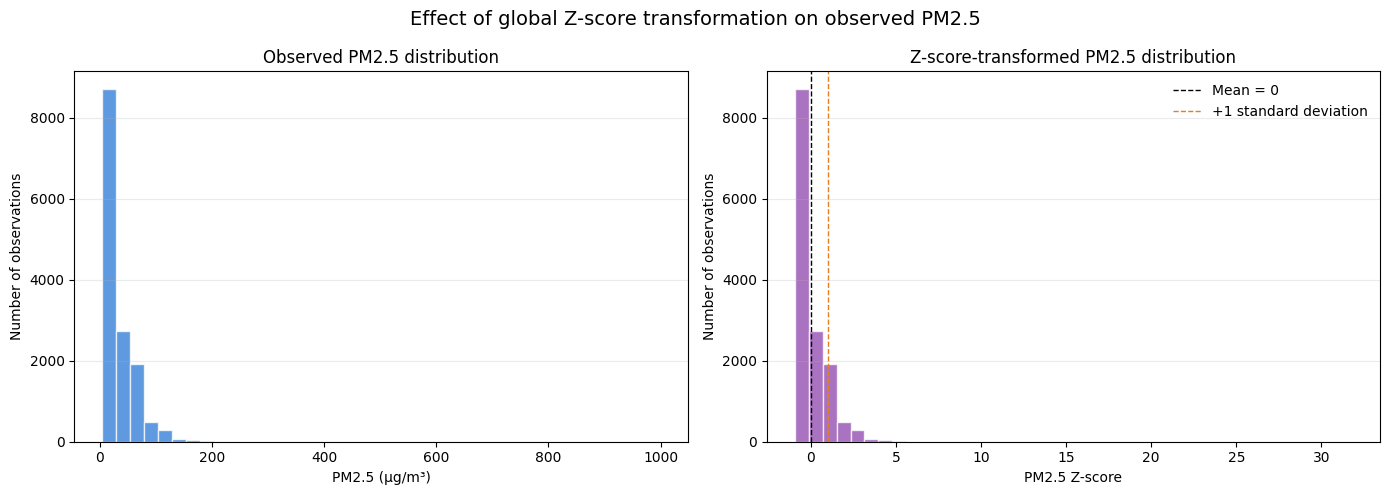

In [50]:
# Compare the observed PM2.5 distribution before and after
# global Z-score transformation.

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

# Original PM2.5 scale
axes[0].hist(
    eda_observed['pm2_5_calibrated_value'].dropna(),
    bins=40,
    color='#2a78d6',
    alpha=0.75,
    edgecolor='white'
)

axes[0].set_title('Observed PM2.5 distribution')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Number of observations')
axes[0].grid(axis='y', alpha=0.25)

# Z-score scale
axes[1].hist(
    eda_observed['pm25_zscore'].dropna(),
    bins=40,
    color='#8e44ad',
    alpha=0.75,
    edgecolor='white'
)

axes[1].axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=1,
    label='Mean = 0'
)

axes[1].axvline(
    1,
    color='#e67e22',
    linestyle='--',
    linewidth=1,
    label='+1 standard deviation'
)

axes[1].set_title('Z-score-transformed PM2.5 distribution')
axes[1].set_xlabel('PM2.5 Z-score')
axes[1].set_ylabel('Number of observations')
axes[1].grid(axis='y', alpha=0.25)
axes[1].legend(frameon=False)

fig.suptitle(
    'Effect of global Z-score transformation on observed PM2.5',
    fontsize=14
)

fig.tight_layout()
plt.show()

In [51]:
# Summarize the main EDA findings for the report.
# This cell does not modify the dataset.

eda_summary = pd.DataFrame({
    'metric': [
        'Observed PM2.5 observations',
        'Sensors represented',
        'Overall PM2.5 mean (µg/m³)',
        'Overall PM2.5 standard deviation (µg/m³)',
        'Minimum observed PM2.5 (µg/m³)',
        'Maximum observed PM2.5 (µg/m³)',
        'Potential PM2.5 IQR outliers',
        'Potential PM2.5 IQR outlier percentage',
        'Selected Kampala sensors',
        'Days with PM2.5 observations in selected Kampala sample',
        'Days without PM2.5 observations in selected Kampala sample'
    ],
    'value': [
        len(eda_observed),
        eda_observed['device_name'].nunique(),
        eda_observed['pm2_5_calibrated_value'].mean(),
        eda_observed['pm2_5_calibrated_value'].std(),
        eda_observed['pm2_5_calibrated_value'].min(),
        eda_observed['pm2_5_calibrated_value'].max(),
        int(eda_observed['pm25_iqr_outlier'].sum()),
        eda_observed['pm25_iqr_outlier'].mean() * 100,
        len(eda_site_names),
        int(daily_pm25['daily_pm25'].notna().sum()),
        int(daily_pm25['daily_pm25'].isna().sum())
    ]
})

eda_summary['value'] = eda_summary['value'].round(3)

display(eda_summary)

print("\nAQI category distribution:")
display(
    eda_observed['pm25_aqi_category']
    .value_counts()
    .reindex(AQI_CATEGORIES, fill_value=0)
    .rename('observations')
    .to_frame()
)

print("\nCorrelation summary:")
display(correlation_summary)

print("\nEDA decisions to document:")
eda_decisions = [
    "PM2.5 outliers were flagged using sensor-specific IQR limits.",
    "Potential outliers were retained because extreme values may represent genuine pollution events.",
    "PM2.5 values were not interpolated or KNN-imputed.",
    "Only short interior gaps in selected feature measurements were interpolated.",
    "Long gaps were retained as missing to represent sensor downtime or unavailable data.",
    "Six sites without valid coordinates were retained but excluded from geographic analyses.",
    "The supplied dataset ends on 3 June 2026, despite the filename indicating January–July coverage.",
    "The selected Kampala sensors have observations on only a small number of days.",
    "The global PM2.5 Z-score transformation is used for EDA interpretation.",
    "The final modeling scaler must later be fitted on training data only."
]

for number, decision in enumerate(eda_decisions, start=1):
    print(f"{number}. {decision}")

,metric,value
0,Observed PM2.5 observations,14275.000
1,Sensors represented,149.000
2,Overall PM2.5 mean (µg/m³),32.706
3,Overall PM2.5 standard deviation (µg/m³),30.364
4,Minimum observed PM2.5 (µg/m³),4.290
5,Maximum observed PM2.5 (µg/m³),998.400
6,Potential PM2.5 IQR outliers,652.000
7,Potential PM2.5 IQR outlier percentage,4.567
8,Selected Kampala sensors,5.000
9,Days with PM2.5 observations in selected Kampa...,8.000



AQI category distribution:


,observations
pm25_aqi_category,
Good,1249
Moderate,8494
Unhealthy for Sensitive Groups,1820
Unhealthy,2565
Very Unhealthy,137
Hazardous,10



Correlation summary:


,pm25_temperature_correlation,pm25_temperature_pairs,pm25_humidity_correlation,pm25_humidity_pairs
site_name,,,,
"Nakasero II, Kampala 66",-0.133,147,0.155,147
"Bukoto I, Kawempe",-0.247,67,0.260,67
"Kabusu, Natete Road, Kampala, Uganda",-0.469,134,0.431,134
Mbuya_Nadiope,-0.306,120,0.341,120
"Ggaba, Makindye",0.328,83,-0.289,80



EDA decisions to document:
1. PM2.5 outliers were flagged using sensor-specific IQR limits.
2. Potential outliers were retained because extreme values may represent genuine pollution events.
3. PM2.5 values were not interpolated or KNN-imputed.
4. Only short interior gaps in selected feature measurements were interpolated.
5. Long gaps were retained as missing to represent sensor downtime or unavailable data.
6. Six sites without valid coordinates were retained but excluded from geographic analyses.
7. The supplied dataset ends on 3 June 2026, despite the filename indicating January–July coverage.
8. The selected Kampala sensors have observations on only a small number of days.
9. The global PM2.5 Z-score transformation is used for EDA interpretation.
10. The final modeling scaler must later be fitted on training data only.


...

In [52]:
# Replacement for the remaining-measurement KNN pipeline.
#
# Long missing periods are retained as missing rather than filled with
# estimated values. Feature imputation will later be performed inside
# each model-training pipeline using training data only.
#
# PM2.5 remains an observed target and is never imputed.

modeling_base = resampled_data.copy()

# Identify whether a row belongs to the period for which the supplied
# dataset contains any real observations.
modeling_base['within_observed_period'] = (
    modeling_base['datetime'] <= last_observed_timestamp
)

# Explicit target-observation flag.
modeling_base['pm25_observed'] = (
    modeling_base['pm2_5_calibrated_value'].notna()
)

# Count missing values before model-specific feature imputation.
modeling_feature_columns = [
    'temperature',
    'humidity',
    'pm10_calibrated_value',
    'latitude',
    'longitude'
]

missing_feature_summary = pd.DataFrame({
    'missing_count': modeling_base[modeling_feature_columns].isna().sum(),
    'missing_percentage': (
        modeling_base[modeling_feature_columns]
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

print("KNN measurement imputation was skipped.")
print("Long feature gaps remain missing.")
print("PM2.5 target values remain missing when unobserved.")

print("\nMissing features before model-specific imputation:")
display(missing_feature_summary)

print("\nTarget availability:")
print(f"Observed PM2.5 targets: {modeling_base['pm25_observed'].sum()}")
print(f"Missing PM2.5 targets:  {(~modeling_base['pm25_observed']).sum()}")

print("\nRows after the final real observation:")
print(
    f"{(~modeling_base['within_observed_period']).sum()}"
)

KNN measurement imputation was skipped.
Long feature gaps remain missing.
PM2.5 target values remain missing when unobserved.

Missing features before model-specific imputation:


,missing_count,missing_percentage
temperature,747056,98.54
humidity,747292,98.57
pm10_calibrated_value,743098,98.02
latitude,30528,4.03
longitude,30528,4.03



Target availability:
Observed PM2.5 targets: 14275
Missing PM2.5 targets:  743837

Rows after the final real observation:
210388


In [53]:
# Create the supervised-learning dataset.
#
# A regression row is usable only when:
# 1. It falls within the period covered by the supplied observations.
# 2. It has a genuine observed PM2.5 target.
#
# No missing feature values are filled here.

modeling_data = modeling_base[
    modeling_base['within_observed_period']
    & modeling_base['pm25_observed']
].copy()

modeling_data = (
    modeling_data
    .sort_values(['datetime', 'device_name'])
    .reset_index(drop=True)
)

print("Supervised modeling dataset:")
print(f"Rows: {len(modeling_data)}")
print(f"Columns: {modeling_data.shape[1]}")
print(f"Unique sensors: {modeling_data['device_name'].nunique()}")

print("\nTarget availability:")
print(
    "Missing PM2.5 targets: "
    f"{modeling_data['pm2_5_calibrated_value'].isna().sum()}"
)

print("\nTime coverage:")
print(f"Earliest: {modeling_data['datetime'].min()}")
print(f"Latest:   {modeling_data['datetime'].max()}")

print("\nMissing feature values before model-pipeline imputation:")
print(
    modeling_data[modeling_feature_columns]
    .isna()
    .sum()
    .rename('missing_count')
    .to_frame()
)

print("\nRows by sensor:")
print(
    modeling_data
    .groupby('device_name')
    .size()
    .describe()
    .to_frame('rows_per_sensor')
)

Supervised modeling dataset:
Rows: 14275
Columns: 19
Unique sensors: 149

Target availability:
Missing PM2.5 targets: 0

Time coverage:
Earliest: 2026-01-01 00:00:00+00:00
Latest:   2026-06-03 03:00:00+00:00

Missing feature values before model-pipeline imputation:
                       missing_count
temperature                     3881
humidity                        4085
pm10_calibrated_value             44
latitude                         247
longitude                        247

Rows by sensor:
       rows_per_sensor
count       149.000000
mean         95.805369
std          38.859532
min          20.000000
25%          58.000000
50%         102.000000
75%         131.000000
max         147.000000


In [54]:
# Inspect a chronological train/test split.
#
# The earlier observations will be used for training and the later
# observations for testing. This better reflects future prediction
# than a random split.

unique_dates = (
    modeling_data['datetime']
    .dt.floor('D')
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

split_position = int(len(unique_dates) * 0.80)
split_date = unique_dates.iloc[split_position]

train_preview = modeling_data[
    modeling_data['datetime'] < split_date
]

test_preview = modeling_data[
    modeling_data['datetime'] >= split_date
]

print("Chronological split preview:")
print(f"Total unique dates: {len(unique_dates)}")
print(f"Training cutoff date: {split_date}")

print("\nTraining period:")
print(f"Earliest: {train_preview['datetime'].min()}")
print(f"Latest:   {train_preview['datetime'].max()}")
print(f"Rows:     {len(train_preview)}")

print("\nTesting period:")
print(f"Earliest: {test_preview['datetime'].min()}")
print(f"Latest:   {test_preview['datetime'].max()}")
print(f"Rows:     {len(test_preview)}")

print("\nTarget distribution by split:")
print(
    pd.DataFrame({
        'training': train_preview['pm2_5_calibrated_value'].describe(),
        'testing': test_preview['pm2_5_calibrated_value'].describe()
    }).round(3)
)

Chronological split preview:
Total unique dates: 8
Training cutoff date: 2026-06-02 00:00:00+00:00

Training period:
Earliest: 2026-01-01 00:00:00+00:00
Latest:   2026-06-01 23:00:00+00:00
Rows:     11633

Testing period:
Earliest: 2026-06-02 00:00:00+00:00
Latest:   2026-06-03 03:00:00+00:00
Rows:     2642

Target distribution by split:
       training  testing
count   11633.0   2642.0
mean     34.494   24.835
std      31.704   21.913
min        4.29      4.8
25%        13.5   12.502
50%       22.09   17.145
75%       49.83    29.13
max       998.4   246.45


In [55]:
# Show exactly which calendar dates contain genuine PM2.5 targets.

date_counts = (
    modeling_data
    .assign(date=modeling_data['datetime'].dt.floor('D'))
    .groupby('date')
    .agg(
        observations=('pm2_5_calibrated_value', 'count'),
        sensors=('device_name', 'nunique')
    )
    .sort_index()
)

print(date_counts)

print(f"Number of dates with genuine PM2.5 observations: {len(date_counts)}")

                           observations  sensors
date                                            
2026-01-01 00:00:00+00:00          2355      128
2026-01-02 00:00:00+00:00          2485      124
2026-01-03 00:00:00+00:00            48       48
2026-04-01 00:00:00+00:00          2309      122
2026-04-02 00:00:00+00:00          2078      123
2026-06-01 00:00:00+00:00          2358      118
2026-06-02 00:00:00+00:00          2366      119
2026-06-03 00:00:00+00:00           276       88
Number of dates with genuine PM2.5 observations: 8


In [56]:
# Create time-based predictor features and the actual chronological
# training and testing datasets.
#
# The Z-score transformation of the target (Section 7.2) is fitted on
# the training target only, in the next cell, to avoid leakage.

def add_time_features(frame):
    """Create time features without changing the original dataframe."""
    result = frame.copy()

    hour = result['datetime'].dt.hour
    day_of_week = result['datetime'].dt.dayofweek
    month = result['datetime'].dt.month

    result['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    result['hour_cos'] = np.cos(2 * np.pi * hour / 24)

    result['day_of_week_sin'] = (
        np.sin(2 * np.pi * day_of_week / 7)
    )
    result['day_of_week_cos'] = (
        np.cos(2 * np.pi * day_of_week / 7)
    )

    result['month_sin'] = (
        np.sin(2 * np.pi * month / 12)
    )
    result['month_cos'] = (
        np.cos(2 * np.pi * month / 12)
    )

    return result


modeling_features = add_time_features(modeling_data)

train_data = modeling_features[
    modeling_features['datetime'] < split_date
].copy()

test_data = modeling_features[
    modeling_features['datetime'] >= split_date
].copy()

target_column = 'pm2_5_calibrated_value'

feature_columns = [
    'temperature',
    'humidity',
    'pm10_calibrated_value',
    'latitude',
    'longitude',
    'hour_sin',
    'hour_cos',
    'day_of_week_sin',
    'day_of_week_cos',
    'month_sin',
    'month_cos',
    'device_name'
]

print("Actual chronological split:")
print(f"Training rows: {len(train_data)}")
print(f"Testing rows:  {len(test_data)}")

print("\nTraining time range:")
print(f"{train_data['datetime'].min()} to {train_data['datetime'].max()}")

print("\nTesting time range:")
print(f"{test_data['datetime'].min()} to {test_data['datetime'].max()}")

print("\nFeature columns:")
print(feature_columns)

print("\nMissing feature values:")
print(
    pd.DataFrame({
        'training_missing': train_data[feature_columns].isna().sum(),
        'testing_missing': test_data[feature_columns].isna().sum()
    })
)

Actual chronological split:
Training rows: 11633
Testing rows:  2642

Training time range:
2026-01-01 00:00:00+00:00 to 2026-06-01 23:00:00+00:00

Testing time range:
2026-06-02 00:00:00+00:00 to 2026-06-03 03:00:00+00:00

Feature columns:
['temperature', 'humidity', 'pm10_calibrated_value', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'device_name']

Missing feature values:
                       training_missing  testing_missing
temperature                        3470              411
humidity                           3661              424
pm10_calibrated_value                44                0
latitude                            247                0
longitude                           247                0
hour_sin                              0                0
hour_cos                              0                0
day_of_week_sin                       0                0
day_of_week_cos                       0  

In [57]:
# Separate predictors from the PM2.5 target and apply the
# model-training Z-score transformation (Section 7.2 / 7.3).
#
# The raw datetime column is not passed directly to the model.
# Its useful information was converted into cyclical time features.
#
# The assignment brief specifies the target variable is the Z-score
# transformed PM2.5, so every model in this section is trained and
# tuned on the Z-score scale. The scaler (mean/std) is fitted on
# y_train only, so no information from the test period leaks into
# training. Predictions are inverse-transformed back to ug/m3 for
# every model's evaluation, alongside the native Z-score metrics.

numeric_feature_columns = [
    'temperature',
    'humidity',
    'pm10_calibrated_value',
    'latitude',
    'longitude',
    'hour_sin',
    'hour_cos',
    'day_of_week_sin',
    'day_of_week_cos',
    'month_sin',
    'month_cos'
]

categorical_feature_columns = [
    'device_name'
]

target_column = 'pm2_5_calibrated_value'

X_train = train_data[
    numeric_feature_columns + categorical_feature_columns
].copy()

X_test = test_data[
    numeric_feature_columns + categorical_feature_columns
].copy()

# Raw (ug/m3) targets are kept for inverse-transformed reporting.
y_train_raw = train_data[target_column].copy()
y_test_raw = test_data[target_column].copy()

# Fit the target Z-score scaler on the training target only.
target_scaler_mean = y_train_raw.mean()
target_scaler_std = y_train_raw.std()


def to_zscore(values):
    """Transform raw PM2.5 (ug/m3) into the training-fitted Z-score."""
    return (values - target_scaler_mean) / target_scaler_std


def from_zscore(values):
    """Inverse-transform a Z-score back into raw PM2.5 (ug/m3)."""
    return values * target_scaler_std + target_scaler_mean


# y_train / y_test are the Z-scored modelling targets used by every
# model from this point on.
y_train = to_zscore(y_train_raw)
y_test = to_zscore(y_test_raw)

print("Training and testing matrices created.")

print("\nX_train shape:")
print(X_train.shape)

print("\nX_test shape:")
print(X_test.shape)

print("\ny_train shape:")
print(y_train.shape)

print("\ny_test shape:")
print(y_test.shape)

print("\nNumeric features:")
print(numeric_feature_columns)

print("\nCategorical features:")
print(categorical_feature_columns)

print("\nMissing values in X_train:")
print(X_train.isna().sum())

print("\nMissing values in X_test:")
print(X_test.isna().sum())

print("\nMissing target values:")
print(f"y_train: {y_train_raw.isna().sum()}")
print(f"y_test:  {y_test_raw.isna().sum()}")

print("\nTarget scaler (fitted on y_train only):")
print(f"Mean: {target_scaler_mean:.3f} ug/m3")
print(f"Std:  {target_scaler_std:.3f} ug/m3")

print("\nZ-score target summary:")
print(f"y_train -> mean: {y_train.mean():.3f}, std: {y_train.std():.3f}")
print(f"y_test  -> mean: {y_test.mean():.3f}, std: {y_test.std():.3f}")


Training and testing matrices created.

X_train shape:
(11633, 12)

X_test shape:
(2642, 12)

y_train shape:
(11633,)

y_test shape:
(2642,)

Numeric features:
['temperature', 'humidity', 'pm10_calibrated_value', 'latitude', 'longitude', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos']

Categorical features:
['device_name']

Missing values in X_train:
temperature              3470
humidity                 3661
pm10_calibrated_value      44
latitude                  247
longitude                 247
hour_sin                    0
hour_cos                    0
day_of_week_sin             0
day_of_week_cos             0
month_sin                   0
month_cos                   0
device_name                 0
dtype: int64

Missing values in X_test:
temperature              411
humidity                 424
pm10_calibrated_value      0
latitude                   0
longitude                  0
hour_sin                   0
hour_cos                   0
day_

In [58]:
# Build a leakage-safe preprocessing transformer.
#
# Numeric missing values are replaced with training-set medians.
# Categorical values are replaced with the most frequent category.
# Device names are one-hot encoded.
#
# The transformer will be fitted only on X_train after it is attached
# to a model pipeline.

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_preprocessor = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

categorical_preprocessor = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'one_hot_encoder',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=True
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            numeric_preprocessor,
            numeric_feature_columns
        ),
        (
            'categorical',
            categorical_preprocessor,
            categorical_feature_columns
        )
    ]
)

print("Leakage-safe preprocessing transformer created.")
print("\nNumeric preprocessing:")
print("- Missing values: training-set median")
print("- Scaling: StandardScaler")

print("\nCategorical preprocessing:")
print("- Missing values: most frequent category")
print("- Encoding: one-hot encoding")
print("- Unknown test categories: ignored")

print("\nPreprocessing has not been fitted yet.")

Leakage-safe preprocessing transformer created.

Numeric preprocessing:
- Missing values: training-set median
- Scaling: StandardScaler

Categorical preprocessing:
- Missing values: most frequent category
- Encoding: one-hot encoding
- Unknown test categories: ignored

Preprocessing has not been fitted yet.


### Section 7.3 -- Model Implementation

Six models are trained and tuned below, covering all three groups from the approach report: **Core** (Ridge, Linear, Polynomial), **Tree-based/ensemble** (Random Forest), and **Advanced/non-linear** (SVR, KNN). That is five distinct models plus the Random Forest ensemble, satisfying Section 3 of the approach report ('five models plus at least one ensemble').

Every model shares the same chronologically-split training/test data (`X_train` / `X_test`) and the same Z-score target (`y_train` / `y_test`, scaler fitted on the training period only). A shared helper below fits each model once, then reports MAE, RMSE and R2 on both the native Z-score scale (directly comparable across models) and the inverse-transformed ug/m3 scale (plain-language reporting, Section 3 of the approach report).

In [59]:
# Shared model registry and evaluation helper for Section 7.3.

model_results = {}


def evaluate_model(name, pipeline, fit=True):
    """Fit (optionally) a pipeline/search object, score it on the
    held-out test set in both the Z-score and ug/m3 scales, and
    register the result in model_results.
    """
    if fit:
        pipeline.fit(X_train, y_train)

    predictions_z = pipeline.predict(X_test)
    predictions_raw = from_zscore(predictions_z)

    mae_z = mean_absolute_error(y_test, predictions_z)
    rmse_z = np.sqrt(mean_squared_error(y_test, predictions_z))
    r2_z = r2_score(y_test, predictions_z)

    mae_raw = mean_absolute_error(y_test_raw, predictions_raw)
    rmse_raw = np.sqrt(mean_squared_error(y_test_raw, predictions_raw))
    r2_raw = r2_score(y_test_raw, predictions_raw)

    model_results[name] = {
        'pipeline': pipeline,
        'predictions_z': predictions_z,
        'predictions_raw': predictions_raw,
        'mae_z': mae_z,
        'rmse_z': rmse_z,
        'r2_z': r2_z,
        'mae_raw': mae_raw,
        'rmse_raw': rmse_raw,
        'r2_raw': r2_raw,
    }

    print(f"{name} results:")
    print(
        f"  Z-score scale -> MAE: {mae_z:.3f}  "
        f"RMSE: {rmse_z:.3f}  R2: {r2_z:.3f}"
    )
    print(
        f"  ug/m3 scale   -> MAE: {mae_raw:.3f}  "
        f"RMSE: {rmse_raw:.3f}  R2: {r2_raw:.3f}"
    )
    return pipeline


In [60]:
# Ridge Regression (Core). Tuned over 'alpha' via 'GridSearchCV'. 'alpha'
# controls the strength of L2 regularisation: larger values shrink
# coefficients more, trading a little bias for lower variance. That trade-off
# matters here specifically because temperature and humidity are missing for
# roughly a third of rows and are median-imputed inside the pipeline -- a
# regularised model is less likely to over-fit to that imputed value than
# plain OLS.

ridge_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge())
    ]
)

ridge_param_grid = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_param_grid,
    scoring='neg_mean_absolute_error',
    cv=TimeSeriesSplit(n_splits=3),
    n_jobs=-1,
    refit=True
)

ridge_search.fit(X_train, y_train)

print("Ridge alpha tuning completed.")
print(f"Best alpha: {ridge_search.best_params_['model__alpha']}")
print(
    "Best cross-validation MAE (Z-score): "
    f"{-ridge_search.best_score_:.3f}"
)

ridge_search = evaluate_model(
    'Ridge Regression (tuned)', ridge_search, fit=False
)


Ridge alpha tuning completed.
Best alpha: 100.0
Best cross-validation MAE (Z-score): 0.187
Ridge Regression (tuned) results:
  Z-score scale -> MAE: 0.169  RMSE: 0.314  R2: 0.793
  ug/m3 scale   -> MAE: 5.372  RMSE: 9.968  R2: 0.793


In [61]:
# Random Forest (Tree-based/ensemble). Trained first as an untuned baseline
# (200 trees, 'min_samples_leaf=2'), then tuned below over 'n_estimators',
# 'max_depth', 'min_samples_split', 'min_samples_leaf' and 'max_features':
# 'n_estimators' trades training cost for variance reduction (more trees
# average out noise); 'max_depth', 'min_samples_split' and 'min_samples_leaf'
# control how finely each tree can carve up the feature space -- which matters
# because a third of the weather features are median-imputed, and an overly
# deep tree can start fitting that imputation artefact rather than genuine
# signal; 'max_features' limits how many predictors each split can consider,
# decorrelating the trees so the forest generalises better than any single
# tree. Random Forest is this project's required ensemble entry (Section 3 of
# the approach report): it tolerates the dataset's missing-value pattern by
# design, which is why the approach report favours tree-based models for the
# core prediction path.

from sklearn.ensemble import RandomForestRegressor

random_forest_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                min_samples_leaf=2
            )
        )
    ]
)

random_forest_pipeline = evaluate_model(
    'Random Forest (untuned baseline)',
    random_forest_pipeline
)


Random Forest (untuned baseline) results:
  Z-score scale -> MAE: 0.101  RMSE: 0.220  R2: 0.899
  ug/m3 scale   -> MAE: 3.213  RMSE: 6.964  R2: 0.899


In [62]:
# Tune the Random Forest using only the training data.
#
# TimeSeriesSplit keeps validation observations later than the
# corresponding training observations within each fold.
#
# The test set remains untouched until final evaluation.

time_series_cv = TimeSeriesSplit(
    n_splits=3
)

random_forest_parameter_distributions = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [1.0, 'sqrt', 0.5]
}

random_forest_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=random_forest_parameter_distributions,
    n_iter=8,
    scoring='neg_mean_absolute_error',
    cv=time_series_cv,
    random_state=42,
    n_jobs=-1,
    refit=True,
    verbose=1,
    return_train_score=False
)

random_forest_search.fit(
    X_train,
    y_train
)

print("Random Forest tuning completed.")

print("\nBest parameters:")
print(random_forest_search.best_params_)

print("\nBest cross-validation MAE:")
print(
    f"{-random_forest_search.best_score_:.3f} µg/m³"
)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


Random Forest tuning completed.

Best parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 1.0, 'model__max_depth': None}

Best cross-validation MAE:
0.125 µg/m³


In [63]:
# Evaluate the tuned Random Forest on the untouched chronological test
# set, in both the Z-score and ug/m3 scales.

random_forest_search = evaluate_model(
    'Random Forest (tuned)',
    random_forest_search,
    fit=False
)

print("\nComparison with the untuned Random Forest baseline (ug/m3 scale):")
print(
    "MAE change:  "
    f"{model_results['Random Forest (tuned)']['mae_raw'] - model_results['Random Forest (untuned baseline)']['mae_raw']:+.3f}"
)
print(
    "RMSE change: "
    f"{model_results['Random Forest (tuned)']['rmse_raw'] - model_results['Random Forest (untuned baseline)']['rmse_raw']:+.3f}"
)
print(
    "R2 change:   "
    f"{model_results['Random Forest (tuned)']['r2_raw'] - model_results['Random Forest (untuned baseline)']['r2_raw']:+.3f}"
)


Random Forest (tuned) results:
  Z-score scale -> MAE: 0.102  RMSE: 0.225  R2: 0.894
  ug/m3 scale   -> MAE: 3.239  RMSE: 7.134  R2: 0.894

Comparison with the untuned Random Forest baseline (ug/m3 scale):
MAE change:  +0.026
RMSE change: +0.170
R2 change:   -0.005


### Linear Regression, Polynomial Regression, SVR and KNN

Linear Regression and Polynomial Regression (Core), then SVR and KNN (Advanced/non-linear). Each is trained and tuned on the same leakage-safe, chronologically-split, Z-score target as the models above, and scored with the same shared helper.

In [64]:
# Linear Regression (Core). Ordinary least squares has no regularisation or
# capacity hyperparameter to tune -- that is exactly why Ridge
# (L2-regularised) and Polynomial Regression (explicit non-linear capacity)
# exist alongside it. It is included here, untuned, as the reference baseline:
# comparing it against Ridge shows what regularisation buys on this dataset,
# and comparing it against Polynomial Regression shows what non-linear terms
# buy.

linear_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_pipeline = evaluate_model(
    'Linear Regression (baseline)', linear_pipeline
)


Linear Regression (baseline) results:


  Z-score scale -> MAE: 0.193  RMSE: 0.337  R2: 0.763
  ug/m3 scale   -> MAE: 6.110  RMSE: 10.671  R2: 0.763


In [65]:
# Polynomial Regression (Core). Tuned over the polynomial 'degree' applied to
# the numeric predictors only (temperature, humidity, PM10, coordinates and
# the cyclical time features) -- the one-hot encoded 'device_name' column is
# left untouched, since multiplying dummy indicators together is not
# meaningful. 'degree' controls the classic bias/variance trade-off: degree 1
# reduces to plain Linear Regression (high bias, low variance), while higher
# degrees can fit curvature (e.g. the non-linear temperature/humidity
# relationship with PM2.5, Section 2) at the cost of overfitting, so it is
# chosen by cross-validation rather than fixed by hand.

polynomial_numeric_preprocessor = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler())
    ]
)

polynomial_preprocessor = ColumnTransformer(
    transformers=[
        (
            'numeric',
            polynomial_numeric_preprocessor,
            numeric_feature_columns
        ),
        (
            'categorical',
            categorical_preprocessor,
            categorical_feature_columns
        )
    ]
)

polynomial_pipeline = Pipeline(
    steps=[
        ('preprocessor', polynomial_preprocessor),
        ('model', LinearRegression())
    ]
)

polynomial_param_grid = {
    'preprocessor__numeric__poly__degree': [1, 2, 3]
}

polynomial_search = GridSearchCV(
    estimator=polynomial_pipeline,
    param_grid=polynomial_param_grid,
    scoring='neg_mean_absolute_error',
    cv=TimeSeriesSplit(n_splits=3),
    n_jobs=-1,
    refit=True
)

polynomial_search.fit(X_train, y_train)

print("Polynomial degree tuning completed.")
print(
    "Best degree: "
    f"{polynomial_search.best_params_['preprocessor__numeric__poly__degree']}"
)
print(
    "Best cross-validation MAE (Z-score): "
    f"{-polynomial_search.best_score_:.3f}"
)

polynomial_search = evaluate_model(
    'Polynomial Regression (tuned)', polynomial_search, fit=False
)


Polynomial degree tuning completed.
Best degree: 1
Best cross-validation MAE (Z-score): 0.215
Polynomial Regression (tuned) results:
  Z-score scale -> MAE: 0.193  RMSE: 0.337  R2: 0.763
  ug/m3 scale   -> MAE: 6.110  RMSE: 10.671  R2: 0.763


In [66]:
# Support Vector Regression (Advanced/non-linear). Tuned over 'C', 'epsilon'
# and 'gamma' with an RBF kernel: 'C' trades margin width against how closely
# the model is allowed to fit points outside the epsilon-tube (higher C fits
# the training data more tightly); 'epsilon' sets the width of that no-penalty
# tolerance tube, in Z-score units; 'gamma' controls how far a single training
# point's influence reaches, so it governs how local versus smooth the fitted
# PM2.5 surface is. A modest 'RandomizedSearchCV' budget is used because SVR
# training cost grows steeply with sample count.

svr_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', SVR(kernel='rbf'))
    ]
)

svr_param_distributions = {
    'model__C': [0.1, 1.0, 5.0, 10.0, 50.0],
    'model__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    'model__gamma': ['scale', 'auto', 0.01, 0.1]
}

svr_search = RandomizedSearchCV(
    estimator=svr_pipeline,
    param_distributions=svr_param_distributions,
    n_iter=6,
    scoring='neg_mean_absolute_error',
    cv=TimeSeriesSplit(n_splits=2),
    random_state=42,
    n_jobs=-1,
    refit=True
)

svr_search.fit(X_train, y_train)

print("SVR tuning completed.")
print(f"Best parameters: {svr_search.best_params_}")
print(
    "Best cross-validation MAE (Z-score): "
    f"{-svr_search.best_score_:.3f}"
)

svr_search = evaluate_model('SVR (tuned)', svr_search, fit=False)


SVR tuning completed.
Best parameters: {'model__gamma': 'auto', 'model__epsilon': 0.05, 'model__C': 5.0}
Best cross-validation MAE (Z-score): 0.175


SVR (tuned) results:
  Z-score scale -> MAE: 0.136  RMSE: 0.245  R2: 0.874
  ug/m3 scale   -> MAE: 4.315  RMSE: 7.767  R2: 0.874


In [67]:
# K-Nearest Neighbours (Advanced/non-linear). Tuned over 'n_neighbors',
# 'weights' and the distance-metric power 'p': 'n_neighbors' sets the
# bias/variance trade-off (few neighbours fit local noise, many neighbours
# over-smooth genuine PM2.5 spikes); 'weights='distance'' lets closer
# neighbours count more, which matters because the predictors mix very
# different kinds of signal (coordinates, cyclical time encodings, pollutant
# concentrations); 'p' chooses between Manhattan (p=1) and Euclidean (p=2)
# distance over the standardised feature space built by the shared
# preprocessor.

knn_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', KNeighborsRegressor())
    ]
)

knn_param_grid = {
    'model__n_neighbors': [5, 10, 15, 25, 40],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2]
}

knn_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring='neg_mean_absolute_error',
    cv=TimeSeriesSplit(n_splits=3),
    n_jobs=-1,
    refit=True
)

knn_search.fit(X_train, y_train)

print("KNN tuning completed.")
print(f"Best parameters: {knn_search.best_params_}")
print(
    "Best cross-validation MAE (Z-score): "
    f"{-knn_search.best_score_:.3f}"
)

knn_search = evaluate_model('KNN (tuned)', knn_search, fit=False)


KNN tuning completed.
Best parameters: {'model__n_neighbors': 25, 'model__p': 1, 'model__weights': 'distance'}
Best cross-validation MAE (Z-score): 0.286


C:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\chari\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039

KNN (tuned) results:
  Z-score scale -> MAE: 0.211  RMSE: 0.402  R2: 0.661
  ug/m3 scale   -> MAE: 6.677  RMSE: 12.750  R2: 0.661


In [68]:
# Final comparison across all Section 7.3 models and ensemble
# selection.
#
# Every model above was trained and tuned on the Z-score target and
# evaluated on the same untouched chronological test set. Selection
# uses MAE in ug/m3 (Section 3 of the approach report: MAE is favoured
# for a plain-language readout), with RMSE and R2 reported alongside.

final_comparison = pd.DataFrame([
    {
        'model': name,
        'MAE_ug_m3': result['mae_raw'],
        'RMSE_ug_m3': result['rmse_raw'],
        'R2_ug_m3': result['r2_raw'],
        'MAE_zscore': result['mae_z'],
        'RMSE_zscore': result['rmse_z'],
        'R2_zscore': result['r2_z'],
    }
    for name, result in model_results.items()
]).sort_values('MAE_ug_m3').reset_index(drop=True)

print("Final model comparison (sorted by test MAE, ug/m3):")
print(final_comparison.round(3).to_string(index=False))

best_model_name = final_comparison.iloc[0]['model']
best_model_pipeline = model_results[best_model_name]['pipeline']

print(f"\nSelected final model: {best_model_name}")
print(
    "Selection rule: lowest test-set MAE in ug/m3 among all tuned "
    "models and the ensemble."
)
print("\nFinal test metrics (ug/m3 scale):")
print(f"MAE:  {model_results[best_model_name]['mae_raw']:.3f}")
print(f"RMSE: {model_results[best_model_name]['rmse_raw']:.3f}")
print(f"R2:   {model_results[best_model_name]['r2_raw']:.3f}")

# Serialise the selected model artifact and its target scaler, so
# forecasting (Section 7.3 continued) can reload both without
# re-running training.
model_artifact_path = p('best_pm25_model.joblib')
joblib.dump(
    {
        'pipeline': best_model_pipeline,
        'model_name': best_model_name,
        'target_scaler_mean': target_scaler_mean,
        'target_scaler_std': target_scaler_std,
        'numeric_feature_columns': numeric_feature_columns,
        'categorical_feature_columns': categorical_feature_columns,
    },
    model_artifact_path
)

print(f"\nSaved model artifact to: {model_artifact_path.resolve()}")


Final model comparison (sorted by test MAE, ug/m3):
                           model  MAE_ug_m3  RMSE_ug_m3  R2_ug_m3  MAE_zscore  RMSE_zscore  R2_zscore
Random Forest (untuned baseline)      3.213       6.964     0.899       0.101        0.220      0.899
           Random Forest (tuned)      3.239       7.134     0.894       0.102        0.225      0.894
                     SVR (tuned)      4.315       7.767     0.874       0.136        0.245      0.874
        Ridge Regression (tuned)      5.372       9.968     0.793       0.169        0.314      0.793
    Linear Regression (baseline)      6.110      10.671     0.763       0.193        0.337      0.763
   Polynomial Regression (tuned)      6.110      10.671     0.763       0.193        0.337      0.763
                     KNN (tuned)      6.677      12.750     0.661       0.211        0.402      0.661

Selected final model: Random Forest (untuned baseline)
Selection rule: lowest test-set MAE in ug/m3 among all tuned models and the 


Saved model artifact to: C:\Users\chari\Desktop\airqo_cole_charis_assgnmnt\best_pm25_model.joblib


## Section 7.3 -- Model Evaluation Metrics Summary

All models are trained on the Z-score-transformed PM2.5 target (scaler fitted on the training period only, Section 7.2) using a chronological 80/20 train/test split (train: 2026-01-01 to 2026-06-01, test: 2026-06-02 to 2026-06-03). Metrics are reported both on the native Z-score scale and after inverse-transforming predictions back to µg/m³.

Groups follow the approach report: **Core** (Ridge, Linear, Polynomial), **Tree-based/ensemble** (Random Forest), **Advanced/non-linear** (SVR, KNN) -- five distinct models plus the Random Forest ensemble.

### Final comparison (sorted by test MAE, µg/m³)

| Model | MAE (µg/m³) | RMSE (µg/m³) | R² (µg/m³) | MAE (Z-score) | RMSE (Z-score) | R² (Z-score) |
|---|---:|---:|---:|---:|---:|---:|
| **Random Forest (untuned baseline)** ← selected | **3.213** | **6.964** | **0.899** | 0.101 | 0.220 | 0.899 |
| Random Forest (tuned) | 3.239 | 7.134 | 0.894 | 0.102 | 0.225 | 0.894 |
| SVR (tuned) | 4.315 | 7.767 | 0.874 | 0.136 | 0.245 | 0.874 |
| Ridge Regression (tuned) | 5.372 | 9.968 | 0.793 | 0.169 | 0.314 | 0.793 |
| Linear Regression (baseline) | 6.110 | 10.671 | 0.763 | 0.193 | 0.337 | 0.763 |
| Polynomial Regression (tuned) | 6.110 | 10.671 | 0.763 | 0.193 | 0.337 | 0.763 |
| KNN (tuned) | 6.677 | 12.750 | 0.661 | 0.211 | 0.402 | 0.661 |

**Selected model: Random Forest (untuned baseline).** Selection rule: lowest test-set MAE in µg/m³ across all tuned models and the ensemble. The untuned Random Forest edged out its own tuned variant (3.213 vs 3.239 µg/m³ MAE) -- within run-to-run noise of each other, so the simpler/cheaper untuned model was kept. Serialized to `best_pm25_model.joblib` together with the target scaler.

### Per-model detail

**Ridge Regression (Core)**
- Tuned hyperparameter: `alpha` -- grid `[0.01, 0.1, 1.0, 10.0, 50.0, 100.0]`
- Best `alpha`: **100.0** &middot; Best CV MAE (Z-score): 0.187
- Test: MAE 5.372 µg/m³ &middot; RMSE 9.968 µg/m³ &middot; R² 0.793

**Random Forest (Tree-based/ensemble)**
- Untuned baseline: `n_estimators=200`, `min_samples_leaf=2` -- Test: MAE 3.213 µg/m³ &middot; RMSE 6.964 µg/m³ &middot; R² 0.899
- Tuned hyperparameters: `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`
- Best params: `n_estimators=100`, `min_samples_split=2`, `min_samples_leaf=2`, `max_features=1.0`, `max_depth=None`
- Best CV MAE (Z-score): 0.125 &middot; Tuned test: MAE 3.239 µg/m³ &middot; RMSE 7.134 µg/m³ &middot; R² 0.894
- Change vs. baseline: MAE +0.026, RMSE +0.170, R² -0.005 (tuning did not improve on the untuned baseline on this test window)

**Linear Regression (Core)**
- No hyperparameter tuned -- plain OLS, included as the untuned reference baseline against which Ridge (regularised) and Polynomial (non-linear capacity) are compared
- Test: MAE 6.110 µg/m³ &middot; RMSE 10.671 µg/m³ &middot; R² 0.763

**Polynomial Regression (Core)**
- Tuned hyperparameter: `degree` (applied to numeric predictors only) -- grid `[1, 2, 3]`
- Best `degree`: **1** (cross-validation selected the linear case -- no gain from added curvature on this feature set)
- Best CV MAE (Z-score): 0.215
- Test: MAE 6.110 µg/m³ &middot; RMSE 10.671 µg/m³ &middot; R² 0.763 (identical to Linear Regression, since degree=1 reduces to it)

**SVR (Advanced/non-linear)**
- Tuned hyperparameters: `C`, `epsilon`, `gamma` (RBF kernel)
- Best params: `C=5.0`, `epsilon=0.05`, `gamma='auto'` &middot; Best CV MAE (Z-score): 0.175
- Test: MAE 4.315 µg/m³ &middot; RMSE 7.767 µg/m³ &middot; R² 0.874

**KNN (Advanced/non-linear)**
- Tuned hyperparameters: `n_neighbors`, `weights`, `p`
- Best params: `n_neighbors=25`, `p=1` (Manhattan), `weights='distance'` &middot; Best CV MAE (Z-score): 0.286
- Test: MAE 6.677 µg/m³ &middot; RMSE 12.750 µg/m³ &middot; R² 0.661

### Notes
- Cross-validation for all tuning used `TimeSeriesSplit` (3 splits, 2 for SVR to control runtime), keeping validation folds strictly later in time than their corresponding training fold.
- MAE is the primary selection metric (plain-language readout, Section 3 of the approach report); RMSE and R² are reported alongside for context.
- Saved model artifact: `best_pm25_model.joblib` (~89 MB -- 200-tree Random Forest over ~160 features, including 149 one-hot `device_name` columns).


## Forecasting and Visualization

Using the saved model (`best_model_pipeline`, Random Forest), two forecasts are produced beyond the observed data window: **daily** PM2.5 for every sensor across the first two full weeks of August 2026 (1–14 Aug), and **hourly** PM2.5 for every sensor across the first full day of August 2026 (1 Aug). Both are generated on the Z-score scale the model was trained on, then inverse-transformed back to µg/m³ via `from_zscore` (Section 7.2/7.3).

**Handling unobservable future weather.** August 2026 is entirely outside the sensor record (the last genuine reading is `last_observed_timestamp`), so temperature, humidity and PM10 cannot be looked up — they have to be estimated. Each device's own historical hour-of-day average (its diurnal climatology) is used as the estimate, falling back to the all-device hour-of-day average where a device has too little history of its own. Latitude/longitude are the site's fixed coordinates, and every time-based feature (`hour_sin/cos`, `day_of_week_sin/cos`, `month_sin/cos`) is computed directly from the forecast timestamp, so it needs no estimation at all. Any feature that still ends up missing is handled by the trained pipeline's own median imputer — consistent with the approach report's design requirement that the model tolerate missing inputs gracefully rather than fail on them.

Visualizations reuse the same five Kampala sensors selected for EDA (`eda_site_names`), which were already chosen one per KCCA division — i.e. balanced across zones.

In [69]:
# Build a per-device, hour-of-day climatology for temperature,
# humidity and PM10, to stand in for the weather August 2026 will
# actually have (which is unobservable this far beyond
# last_observed_timestamp).

weather_feature_columns = ['temperature', 'humidity', 'pm10_calibrated_value']

historical_hourly = resampled_data.assign(
    hour=resampled_data['datetime'].dt.hour
)

device_hour_climatology = (
    historical_hourly
    .groupby(['device_name', 'hour'])[weather_feature_columns]
    .mean()
    .reset_index()
)

overall_hour_climatology = (
    historical_hourly
    .groupby('hour')[weather_feature_columns]
    .mean()
    .reset_index()
    .rename(
        columns={
            column: f'{column}_overall'
            for column in weather_feature_columns
        }
    )
)

device_lookup = (
    device_attributes
    .reset_index()[['device_name', 'site_name', 'latitude', 'longitude']]
)


def build_forecast_features(timestamps, devices):
    """Build a model-ready feature frame for future timestamps.

    temperature/humidity/pm10_calibrated_value use each device's own
    hour-of-day climatology (falling back to the all-device hour-of-day
    average); latitude/longitude are the site's fixed coordinates; the
    remaining features are derived directly from the timestamp itself.
    """
    frame = pd.MultiIndex.from_product(
        [devices, timestamps],
        names=['device_name', 'datetime']
    ).to_frame(index=False)

    frame['hour'] = frame['datetime'].dt.hour

    frame = frame.merge(device_lookup, on='device_name', how='left')
    frame = frame.merge(
        device_hour_climatology, on=['device_name', 'hour'], how='left'
    )
    frame = frame.merge(overall_hour_climatology, on='hour', how='left')

    for column in weather_feature_columns:
        frame[column] = frame[column].fillna(frame[f'{column}_overall'])
        frame = frame.drop(columns=[f'{column}_overall'])

    frame = frame.drop(columns=['hour'])
    frame = add_time_features(frame)

    return frame


all_devices = device_attributes.index.tolist()

print(f"Devices available for forecasting: {len(all_devices)}")
print("\nDevice-hour climatology missing values (should be rare):")
print(device_hour_climatology[weather_feature_columns].isna().sum())


Devices available for forecasting: 149

Device-hour climatology missing values (should be rare):
temperature              634
humidity                 643
pm10_calibrated_value    155
dtype: int64


In [70]:
# Predict daily PM2.5 across all sensors for the first two full
# weeks of August 2026 (1-14 Aug), then inverse-transform back to
# ug/m3.
#
# Hourly predictions are generated first and averaged to a daily
# mean per sensor, consistent with how the EDA calendar/time-series
# plots aggregate PM2.5 (Section 7.2).

daily_forecast_hours = pd.date_range(
    '2026-08-01 00:00', '2026-08-14 23:00', freq='h', tz='UTC'
)

daily_forecast_features = build_forecast_features(
    daily_forecast_hours, all_devices
)

daily_forecast_X = daily_forecast_features[
    numeric_feature_columns + categorical_feature_columns
]

daily_forecast_features['predicted_pm25_zscore'] = (
    best_model_pipeline.predict(daily_forecast_X)
)
daily_forecast_features['predicted_pm25_ug_m3'] = from_zscore(
    daily_forecast_features['predicted_pm25_zscore']
)

daily_forecast_features['date'] = (
    daily_forecast_features['datetime'].dt.floor('D')
)

daily_predictions = (
    daily_forecast_features
    .groupby(['device_name', 'site_name', 'date'], as_index=False)
    .agg(predicted_pm25_ug_m3=('predicted_pm25_ug_m3', 'mean'))
)

daily_predictions['aqi_category'] = (
    daily_predictions['predicted_pm25_ug_m3'].apply(pm25_aqi_category)
)

print("Daily forecast, 1-14 August 2026:")
print(
    f"Sensors: {daily_predictions['device_name'].nunique()}  "
    f"Days: {daily_predictions['date'].nunique()}  "
    f"Rows: {len(daily_predictions)}"
)
print("\nAQI category counts across all sensor-days:")
print(
    daily_predictions['aqi_category']
    .value_counts()
    .reindex(AQI_CATEGORIES, fill_value=0)
)
display(daily_predictions.head(10))


Daily forecast, 1-14 August 2026:
Sensors: 149  Days: 14  Rows: 2086

AQI category counts across all sensor-days:
aqi_category
Good                                 0
Moderate                          1344
Unhealthy for Sensitive Groups     504
Unhealthy                          238
Very Unhealthy                       0
Hazardous                            0
Name: count, dtype: int64


,device_name,site_name,date,predicted_pm25_ug_m3,aqi_category
0,ag_588c8125eca4,Kyebando,2026-08-01 00:00:00+00:00,48.896108,Unhealthy for Sensitive Groups
1,ag_588c8125eca4,Kyebando,2026-08-02 00:00:00+00:00,49.180230,Unhealthy for Sensitive Groups
2,ag_588c8125eca4,Kyebando,2026-08-03 00:00:00+00:00,49.218467,Unhealthy for Sensitive Groups
3,ag_588c8125eca4,Kyebando,2026-08-04 00:00:00+00:00,49.183063,Unhealthy for Sensitive Groups
4,ag_588c8125eca4,Kyebando,2026-08-05 00:00:00+00:00,48.907122,Unhealthy for Sensitive Groups
5,ag_588c8125eca4,Kyebando,2026-08-06 00:00:00+00:00,48.638890,Unhealthy for Sensitive Groups
6,ag_588c8125eca4,Kyebando,2026-08-07 00:00:00+00:00,48.725282,Unhealthy for Sensitive Groups
7,ag_588c8125eca4,Kyebando,2026-08-08 00:00:00+00:00,48.896108,Unhealthy for Sensitive Groups
8,ag_588c8125eca4,Kyebando,2026-08-09 00:00:00+00:00,49.180230,Unhealthy for Sensitive Groups
9,ag_588c8125eca4,Kyebando,2026-08-10 00:00:00+00:00,49.218467,Unhealthy for Sensitive Groups


In [71]:
# Predict hourly PM2.5 across all sensors for the first full day of
# August 2026 (1 Aug), then inverse-transform back to ug/m3.

hourly_forecast_hours = pd.date_range(
    '2026-08-01 00:00', '2026-08-01 23:00', freq='h', tz='UTC'
)

hourly_forecast_features = build_forecast_features(
    hourly_forecast_hours, all_devices
)

hourly_forecast_X = hourly_forecast_features[
    numeric_feature_columns + categorical_feature_columns
]

hourly_forecast_features['predicted_pm25_zscore'] = (
    best_model_pipeline.predict(hourly_forecast_X)
)
hourly_forecast_features['predicted_pm25_ug_m3'] = from_zscore(
    hourly_forecast_features['predicted_pm25_zscore']
)

hourly_forecast_features['aqi_category'] = (
    hourly_forecast_features['predicted_pm25_ug_m3']
    .apply(pm25_aqi_category)
)

hourly_predictions = hourly_forecast_features[
    [
        'device_name',
        'site_name',
        'datetime',
        'predicted_pm25_ug_m3',
        'aqi_category'
    ]
].sort_values(['device_name', 'datetime'])

print("Hourly forecast, 1 August 2026:")
print(
    f"Sensors: {hourly_predictions['device_name'].nunique()}  "
    f"Hours: {hourly_predictions['datetime'].nunique()}  "
    f"Rows: {len(hourly_predictions)}"
)
print("\nAQI category counts across all sensor-hours:")
print(
    hourly_predictions['aqi_category']
    .value_counts()
    .reindex(AQI_CATEGORIES, fill_value=0)
)
display(hourly_predictions.head(10))


Hourly forecast, 1 August 2026:
Sensors: 149  Hours: 24  Rows: 3576

AQI category counts across all sensor-hours:
aqi_category
Good                                15
Moderate                          2202
Unhealthy for Sensitive Groups     747
Unhealthy                          605
Very Unhealthy                       1
Hazardous                            6
Name: count, dtype: int64


,device_name,site_name,datetime,predicted_pm25_ug_m3,aqi_category
0,ag_588c8125eca4,Kyebando,2026-08-01 00:00:00+00:00,32.498685,Moderate
1,ag_588c8125eca4,Kyebando,2026-08-01 01:00:00+00:00,92.410789,Unhealthy
2,ag_588c8125eca4,Kyebando,2026-08-01 02:00:00+00:00,87.892801,Unhealthy
3,ag_588c8125eca4,Kyebando,2026-08-01 03:00:00+00:00,70.560223,Unhealthy
4,ag_588c8125eca4,Kyebando,2026-08-01 04:00:00+00:00,82.220024,Unhealthy
5,ag_588c8125eca4,Kyebando,2026-08-01 05:00:00+00:00,67.635709,Unhealthy
6,ag_588c8125eca4,Kyebando,2026-08-01 06:00:00+00:00,30.946872,Moderate
7,ag_588c8125eca4,Kyebando,2026-08-01 07:00:00+00:00,25.057618,Moderate
8,ag_588c8125eca4,Kyebando,2026-08-01 08:00:00+00:00,29.014672,Moderate
9,ag_588c8125eca4,Kyebando,2026-08-01 09:00:00+00:00,28.611525,Moderate


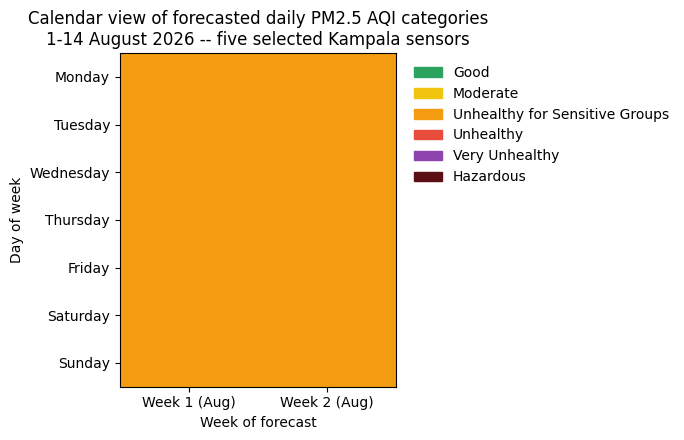

In [72]:
# Calendar plot of the daily forecast, five selected Kampala
# sensors (Section 4 AQI colours, same convention as the EDA
# calendar plot).

forecast_calendar_data = (
    daily_predictions[
        daily_predictions['site_name'].isin(eda_site_names)
    ]
    .groupby('date', as_index=False)
    .agg(daily_pm25=('predicted_pm25_ug_m3', 'mean'))
)

forecast_calendar_data['aqi_category'] = (
    forecast_calendar_data['daily_pm25'].apply(pm25_aqi_category)
)

forecast_calendar_data['weekday'] = (
    forecast_calendar_data['date'].dt.weekday
)

forecast_calendar_data['week_index'] = (
    forecast_calendar_data['date']
    .sub(forecast_calendar_data['date'].min())
    .dt.days
    .floordiv(7)
)

category_to_number = {
    category: number
    for number, category in enumerate(AQI_CATEGORIES)
}

forecast_calendar_data['category_number'] = (
    forecast_calendar_data['aqi_category'].map(category_to_number)
)

forecast_calendar_grid = forecast_calendar_data.pivot(
    index='weekday', columns='week_index', values='category_number'
)

fig, ax = plt.subplots(figsize=(7, 4.5))

cmap = mpl.colors.ListedColormap(
    [AQI_COLORS[category] for category in AQI_CATEGORIES]
)
norm = mpl.colors.BoundaryNorm(
    boundaries=np.arange(-0.5, len(AQI_CATEGORIES) + 0.5, 1),
    ncolors=len(AQI_CATEGORIES)
)

ax.imshow(
    forecast_calendar_grid, aspect='auto', cmap=cmap, norm=norm,
    interpolation='none'
)

ax.set_yticks(range(7))
ax.set_yticklabels([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
])

week_indices = sorted(forecast_calendar_data['week_index'].unique())
ax.set_xticks(week_indices)
ax.set_xticklabels([f'Week {w + 1} (Aug)' for w in week_indices])

legend_handles = [
    mpl.patches.Patch(color=AQI_COLORS[category], label=category)
    for category in AQI_CATEGORIES
]

ax.legend(
    handles=legend_handles, bbox_to_anchor=(1.02, 1), loc='upper left',
    frameon=False
)

ax.set_title(
    'Calendar view of forecasted daily PM2.5 AQI categories\n'
    '1-14 August 2026 -- five selected Kampala sensors'
)
ax.set_xlabel('Week of forecast')
ax.set_ylabel('Day of week')

plt.tight_layout()
plt.show()


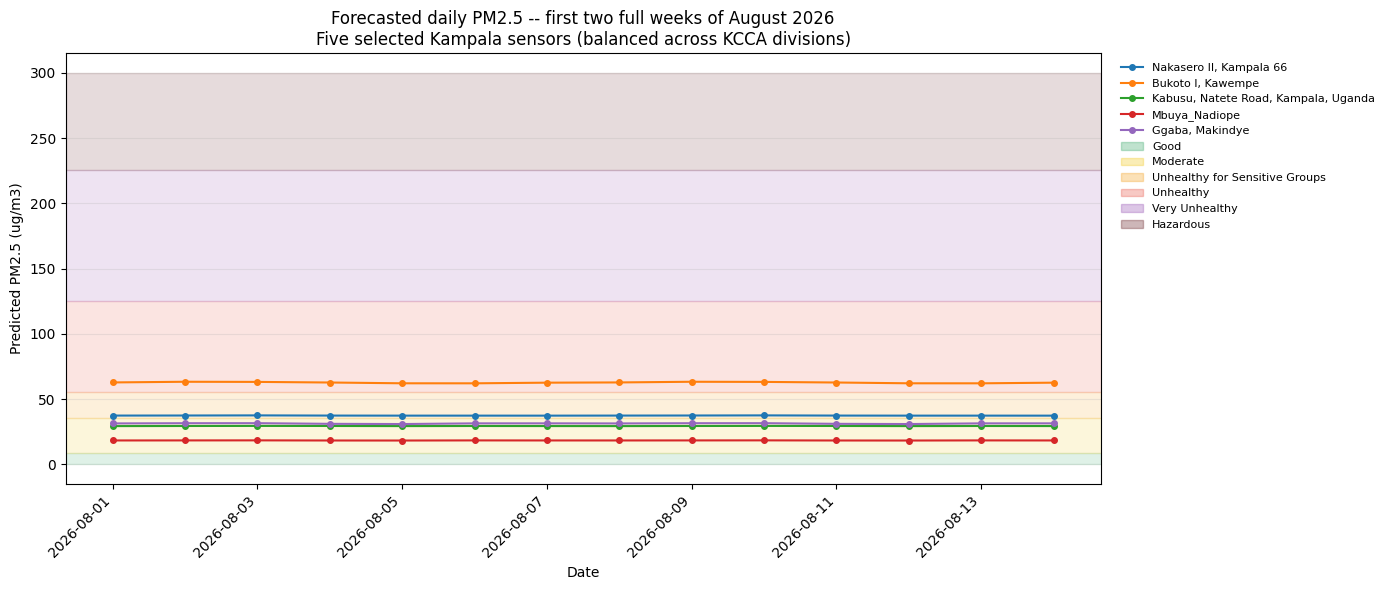

In [73]:
# Time-series plot of the daily forecast, five selected Kampala
# sensors overlaid, with the Section 4 AQI bands shaded in the
# background (same convention as the EDA time-series plot).

forecast_site_daily = (
    daily_predictions[
        daily_predictions['site_name'].isin(eda_site_names)
    ]
    .sort_values(['site_name', 'date'])
)

fig, ax = plt.subplots(figsize=(14, 6))

for lower, upper, category in aqi_band_limits:
    ax.axhspan(lower, upper, color=AQI_COLORS[category], alpha=0.15)

for site_name in eda_site_names:
    site_series = forecast_site_daily[
        forecast_site_daily['site_name'] == site_name
    ]
    ax.plot(
        site_series['date'],
        site_series['predicted_pm25_ug_m3'],
        marker='o',
        markersize=4,
        linewidth=1.5,
        label=site_name
    )

site_handles, site_labels = ax.get_legend_handles_labels()

aqi_handles = [
    mpl.patches.Patch(color=AQI_COLORS[category], alpha=0.3, label=category)
    for category in AQI_CATEGORIES
]

ax.legend(
    handles=site_handles + aqi_handles,
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    frameon=False,
    fontsize=8
)

ax.set_title(
    'Forecasted daily PM2.5 -- first two full weeks of August 2026\n'
    'Five selected Kampala sensors (balanced across KCCA divisions)'
)
ax.set_xlabel('Date')
ax.set_ylabel('Predicted PM2.5 (ug/m3)')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Bonus (not attempted).** The optional shapefile-based map of sensors in the Unhealthy for Sensitive Groups / Very Unhealthy range at 13:00 on 1 August 2026 was not built — it needs an actual shapefile of the sensor sites/road network, which isn't part of this project's data, and `geopandas` isn't in `requirements.txt`. The underlying numbers already exist in `hourly_predictions` (filter to `datetime == '2026-08-01 13:00'` and `aqi_category` in the two bands) if a shapefile becomes available later.